In [ ]:
# read csv batches from aave_proposal_batches

# merge the batches into a single dataframe

# create df where each proposal is a transaction and the items are the votes (with voter_id_(FOR\AGAINST\ABSTAIN) and timestamp)

# split proposals into time windows of 10

# calculate the of voters per time window

# Select voters with at least 10 votes (100% support)

# create df where each voter_id has a vector of votes he voted on proposals

# calculate the tsne of the voters

# plot the tsne of the voters for every time window



In [2]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import gc

# Set plot style
sns.set_theme(style="whitegrid")

In [3]:
# Path to the directory containing the batches
batches_path = 'aave_proposal_batches'

# Get all csv files
csv_files = glob.glob(os.path.join(batches_path, "batch_*.csv"))

# Read and merge with specified dtypes to save memory
df_list = []
for file in csv_files:
    # Specifying dtypes helps memory usage and prevents type inference errors
    d = pd.read_csv(file, dtype={
        'Onchain_ID': 'Int64', # Use Int64 to handle NaNs if any
        'Vote_Type': 'category',
        'Voter_Address': 'string'
    })
    df_list.append(d)

df = pd.concat(df_list, ignore_index=True)

# Drop rows where critical data is missing
df = df.dropna(subset=['Onchain_ID', 'Voter_Address', 'Timestamp'])

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(f"Total votes loaded: {len(df)}")
gc.collect() # Free memory
df.head()

Total votes loaded: 26666


,Proposal_Title,Onchain_ID,Voter_Address,Voter_Name,Vote_Type,Voting_Power,Timestamp
0,# Chaos Labs Risk Parameter Updates - Aave V3...,309,0xDf06A761D286C0ae835173236E1f12f1379E4977,planar,for,27288339304972971327,2023-08-31 01:40:59+00:00
1,# Chaos Labs Risk Parameter Updates - Aave V3...,309,0x2cc1ADE245020FC5AAE66Ad443e1F66e01c54Df1,TokenLogic,for,28776430123471773907211,2023-08-31 05:52:23+00:00
2,# Chaos Labs Risk Parameter Updates - Aave V3...,309,0x1855f41B8A86e701E33199DE7C25d3e3830698ba,0xkeyrock.eth,for,3000000000000000000000,2023-08-31 08:12:59+00:00
3,# Chaos Labs Risk Parameter Updates - Aave V3...,309,0x329c54289Ff5D6B7b7daE13592C6B1EDA1543eD4,aavechan.eth,for,107715295474823004312308,2023-08-31 08:53:59+00:00
4,# Chaos Labs Risk Parameter Updates - Aave V3...,309,0x57ab7ee15cE5ECacB1aB84EE42D5A9d0d8112922,ACI,for,23890199652377496162888,2023-08-31 08:54:35+00:00


In [4]:
# Create the "item" string: voter_id_VOTETYPE
df['vote_item'] = df['Voter_Address'] + '_' + df['Vote_Type'].astype(str).str.upper()

# Get proposal metadata (ID -> Title, Start Time)
# We take the minimum timestamp per proposal as the start time
proposal_meta = df.groupby('Onchain_ID').agg({
    'Timestamp': 'min',
    'Proposal_Title': 'first'
}).reset_index().rename(columns={'Timestamp': 'Proposal_Start_Time'})

# Merge meta back
df = df.merge(proposal_meta[['Onchain_ID', 'Proposal_Start_Time']], on='Onchain_ID')

# Sort by time to ensure order
df = df.sort_values(['Proposal_Start_Time', 'Timestamp'])

# Build transactions list manually to avoid memory overhead of apply()
transactions = []
grouped = df.groupby(['Onchain_ID', 'Proposal_Title', 'Proposal_Start_Time'])

print("Building transactions...")
for (onchain_id, title, start_time), group in grouped:
    # Create list of dicts for this proposal
    votes_data = group[['Voter_Address', 'Vote_Type', 'Timestamp', 'vote_item']].to_dict('records')
    
    transactions.append({
        'Onchain_ID': onchain_id,
        'Proposal_Title': title,
        'Proposal_Start_Time': start_time,
        'votes': votes_data
    })

transactions_df = pd.DataFrame(transactions)

# Sort transactions by proposal start time
transactions_df = transactions_df.sort_values('Proposal_Start_Time').reset_index(drop=True)

print(f"Total proposals created: {len(transactions_df)}")
gc.collect()
transactions_df.head()

Building transactions...
Total proposals created: 397


,Onchain_ID,Proposal_Title,Proposal_Start_Time,votes
0,0,# AIP 5: Adding CRV to Aave,2020-12-23 22:48:45+00:00,[{'Voter_Address': '0x2fbB0c60a41cB7Ea53230716...
1,1,# AIP 6: Add Gemini USD (GUSD),2020-12-29 15:48:20+00:00,[{'Voter_Address': '0x8d07D225a769b7Af3A923481...
2,2,# AIP 7: Aavenomics quarterly upgrade,2021-01-06 17:25:28+00:00,[{'Voter_Address': '0x73C59DB79Ca56755429F06CC...
3,3,# Adding BAL on AAVE,2021-01-29 22:09:49+00:00,[{'Voter_Address': '0x21d05071cA08593e13cd3aFD...
4,4,# Activation of the Aave Balancer Pool Liquidi...,2021-02-05 18:01:24+00:00,[{'Voter_Address': '0x39f6be189A5158151CbAa169...


In [5]:
# Split proposals into time windows of 10
window_size = 10
transactions_df['window_id'] = transactions_df.index // window_size

# Calculate number of voters per time window
window_stats = []

for window_id, group in transactions_df.groupby('window_id'):
    unique_voters = set()
    for votes_list in group['votes']:
        for vote in votes_list:
            unique_voters.add(vote['Voter_Address'])
            
    window_stats.append({
        'window_id': window_id,
        'start_date': group['Proposal_Start_Time'].min().date(),
        'end_date': group['Proposal_Start_Time'].max().date(),
        'proposal_count': len(group),
        'unique_voters': len(unique_voters)
    })

df_window_stats = pd.DataFrame(window_stats)
print("Window stats calculated.")
df_window_stats

Window stats calculated.


,window_id,start_date,end_date,proposal_count,unique_voters
0,0,2020-12-23,2021-04-19,10,419
1,1,2021-04-20,2021-07-20,10,317
2,2,2021-07-21,2021-08-31,10,161
3,3,2021-09-06,2021-10-12,10,66
4,4,2021-10-15,2021-11-30,10,64
5,5,2021-12-06,2022-02-18,10,201
6,6,2022-02-22,2022-04-26,10,250
7,7,2022-05-03,2022-06-08,10,282
8,8,2022-06-08,2022-07-26,10,1038
9,9,2022-07-27,2022-09-13,10,1424


Processing Window 0... 

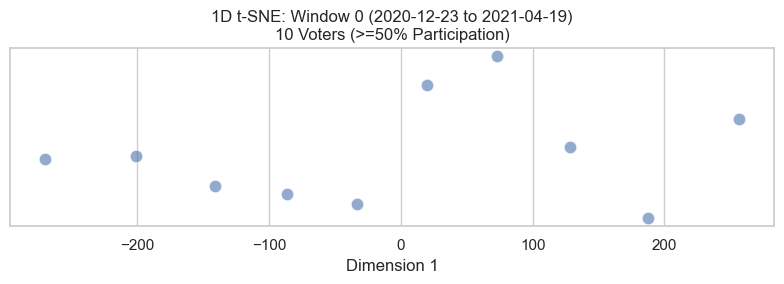

Done.
Processing Window 1... 

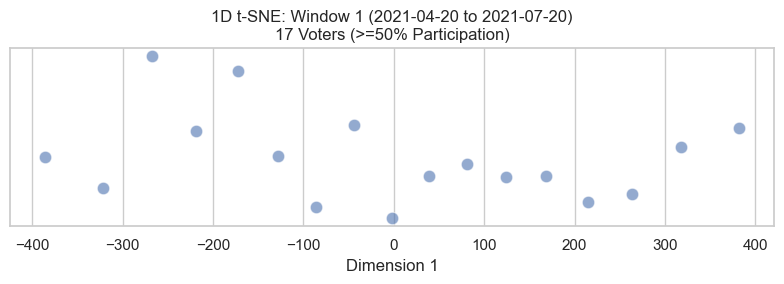

Done.
Processing Window 2... 

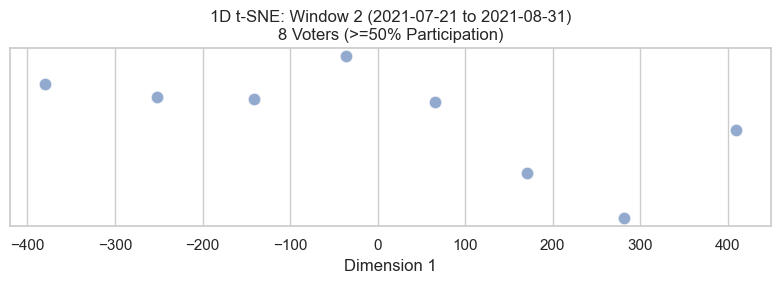

Done.
Processing Window 3... Skipping (Only 3 active voters).
Processing Window 4... 

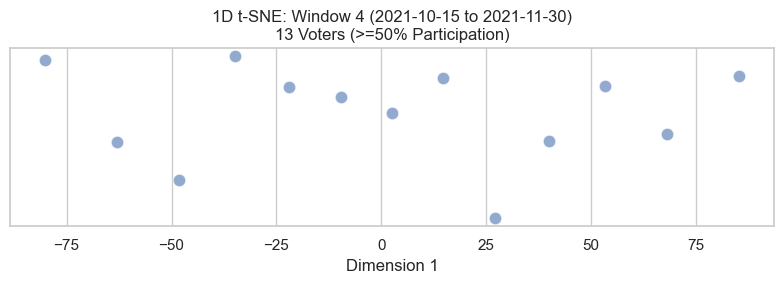

Done.
Processing Window 5... Skipping (Only 4 active voters).
Processing Window 6... 

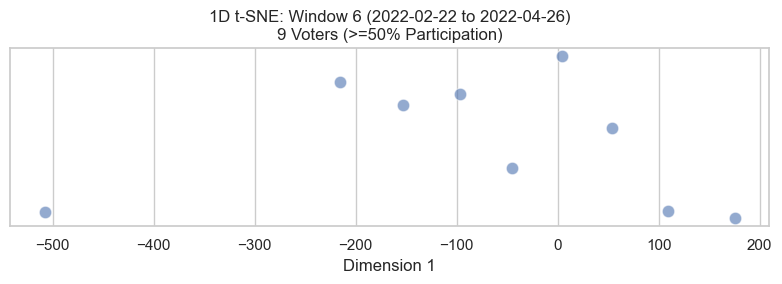

Done.
Processing Window 7... 

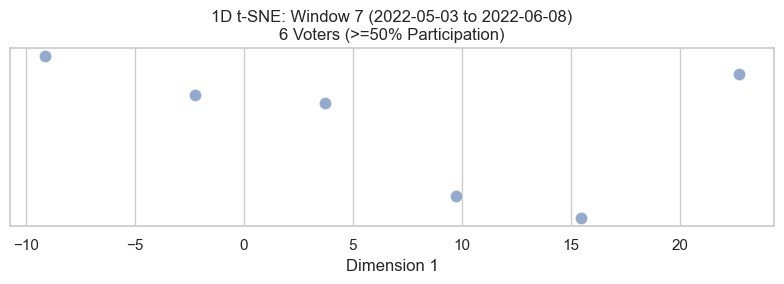

Done.
Processing Window 8... [[ 1  1 -1  1  1  1  1  1  1  1]
 [ 1  0  0  0  1  1  0  1  1  0]
 [ 1  0  0  1  0  1  1  0  1  0]
 [ 1  0  1  1  1  0  0  1  0  0]
 [ 1  1 -1  1  1  1  1  0  0  0]
 [ 1  1  0  1  1  0  1  0  1  1]
 [ 1  1 -1  1  1  1  1  0  0  0]
 [ 1  1 -1  1  1  1  1  0  1  1]
 [ 1  0  1  1  1  0  0  1  0  0]
 [ 1  1 -1  1  1  1  1  0  0  1]
 [ 1  0  1  1  1  0  0  1  0  0]
 [ 1  1 -1  1  1  1  1  0  0  0]
 [ 1  0  1  1  1  0  0  1  0  0]
 [ 1  0  1  1  1  0  0  1  0  0]
 [ 1  0  0  1  0  1  1  0  1  0]
 [ 1  1 -1  1  1  1  1  0  0  0]
 [ 1  1 -1  1  1  1  1  0  0  1]
 [ 1  1 -1  0  0  0  1  1  1  0]
 [ 1  1 -1  1  1  1  1  0  0  1]
 [ 0  1 -1  0  1  1  0  1  0  0]
 [ 0  1 -1  1  0  0  1  0  0  1]
 [ 0  1  1  0  1  0  1  0  1  1]
 [ 0  1 -1  0  1  1  1  1  1  1]
 [ 0  0 -1  0  1  1  1  1  0  1]
 [ 0  0  0  1  1  1  0  0  1  1]
 [ 0  0  0  1  0  1  1  0  1  1]
 [ 0  0  0  1  1  1  0  0  1  1]
 [ 0  0  0  0  1  1  1  1  0  1]
 [ 0  0  0  0  1  1  1  1  0  1]
 [ 0  0  0  0 

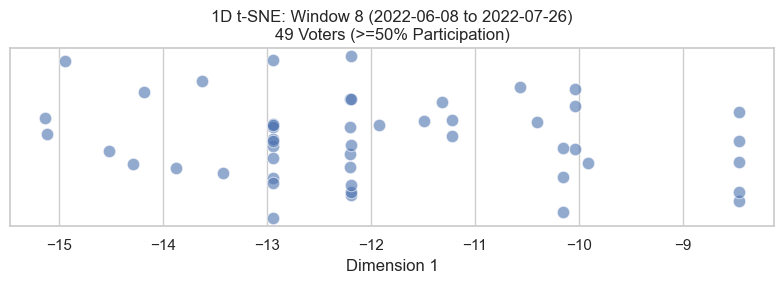

Done.
Processing Window 9... 

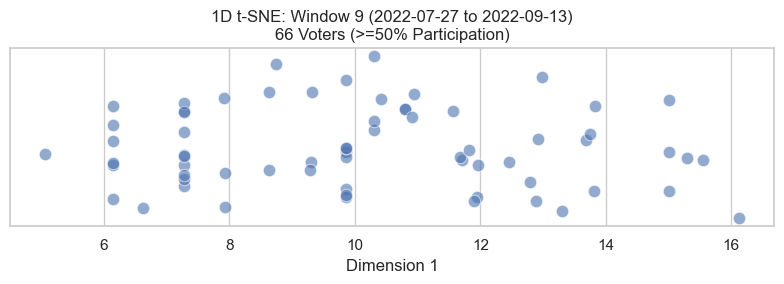

Done.
Processing Window 10... 

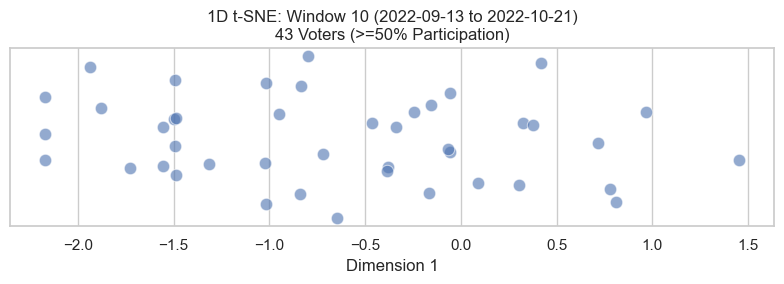

Done.
Processing Window 11... 

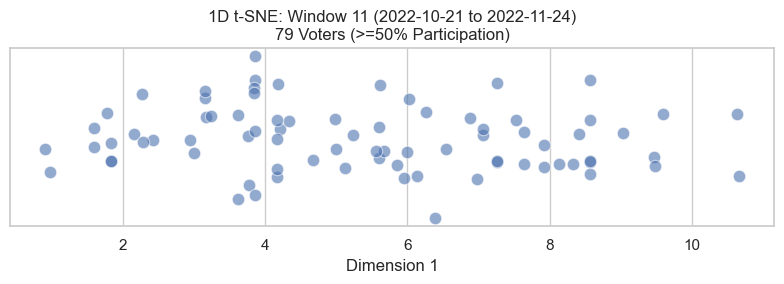

Done.
Processing Window 12... 

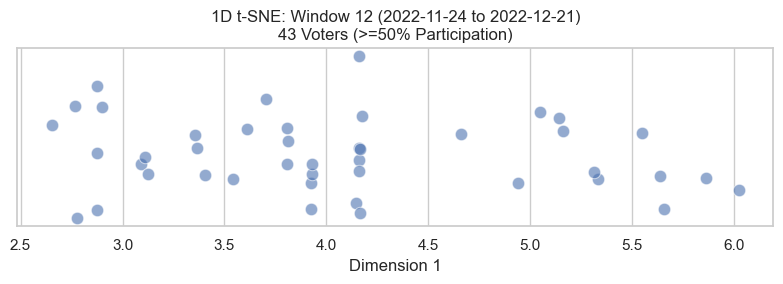

Done.
Processing Window 13... 

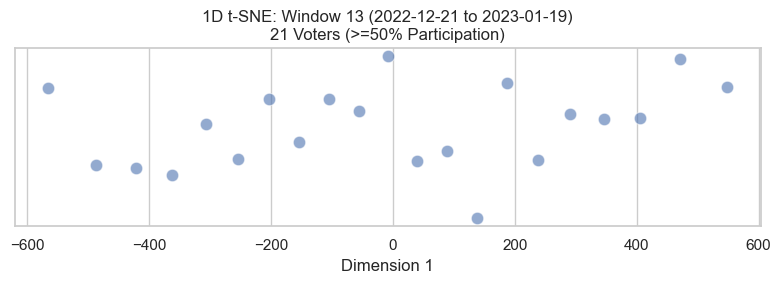

Done.
Processing Window 14... 

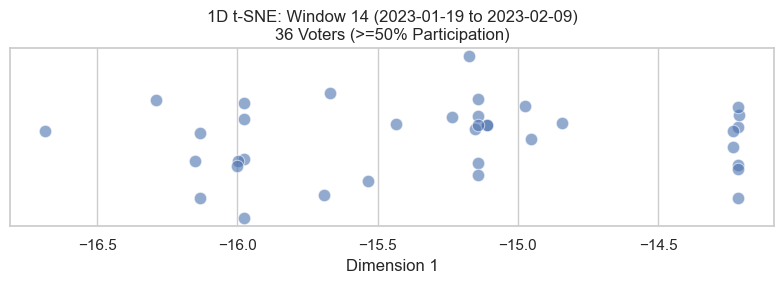

Done.
Processing Window 15... 

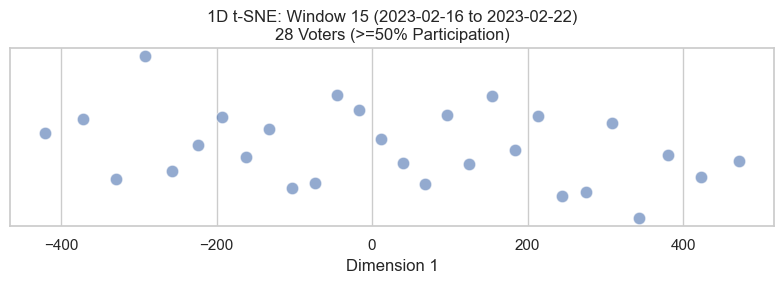

Done.
Processing Window 16... 

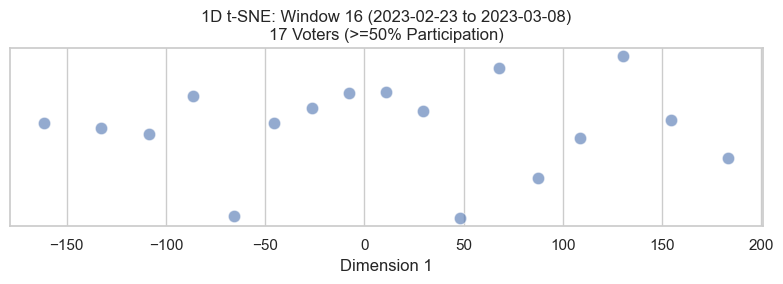

Done.
Processing Window 17... 

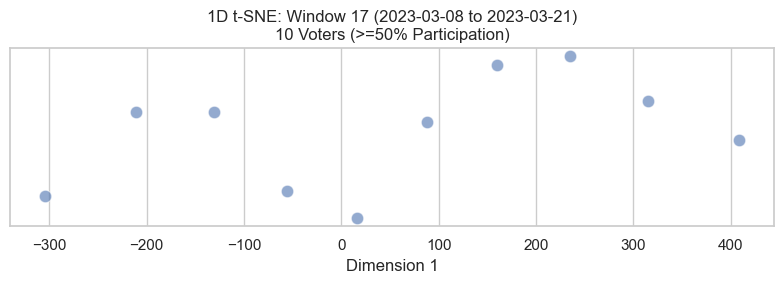

Done.
Processing Window 18... 

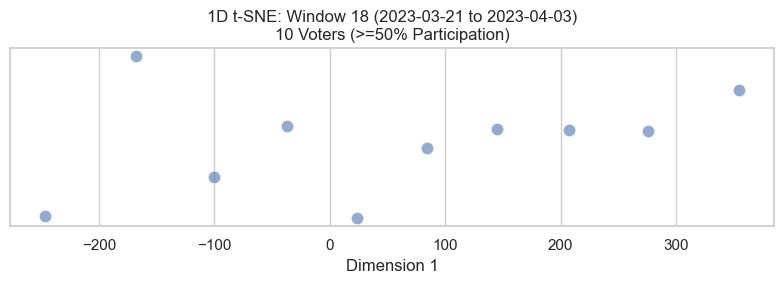

Done.
Processing Window 19... 

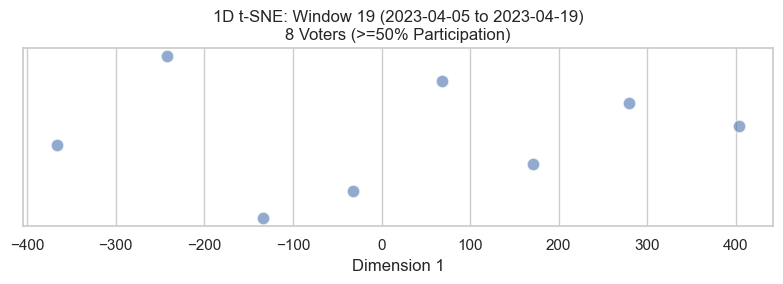

Done.
Processing Window 20... 

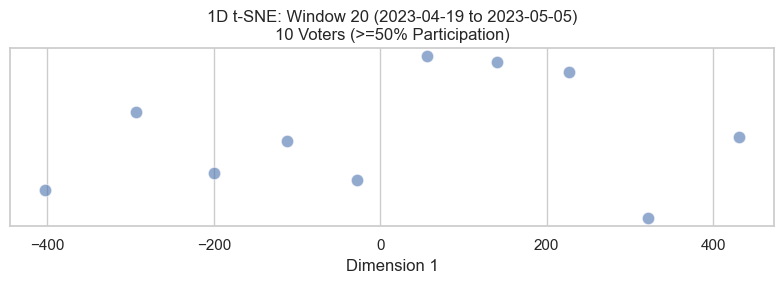

Done.
Processing Window 21... 

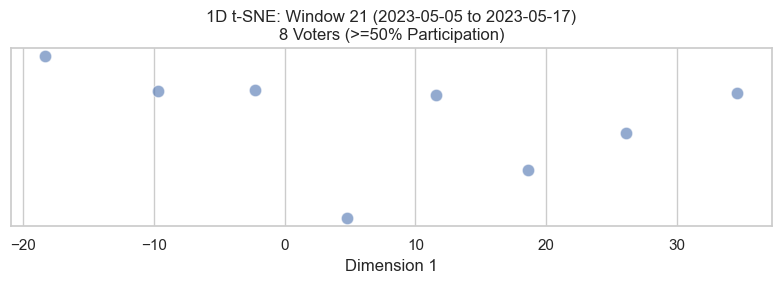

Done.
Processing Window 22... 

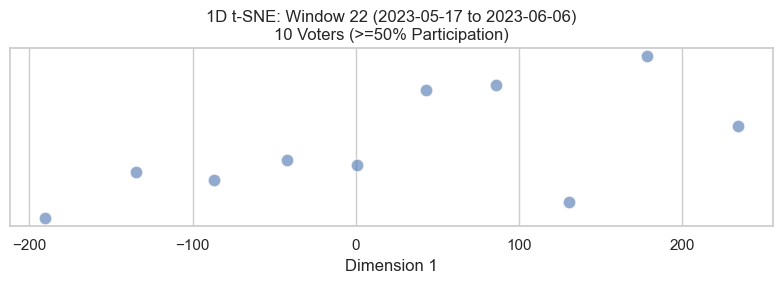

Done.
Processing Window 23... 

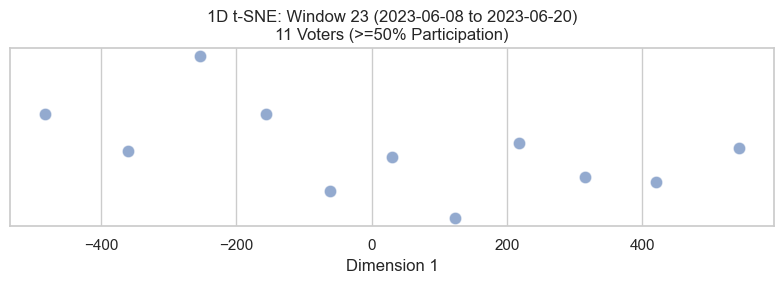

Done.
Processing Window 24... 

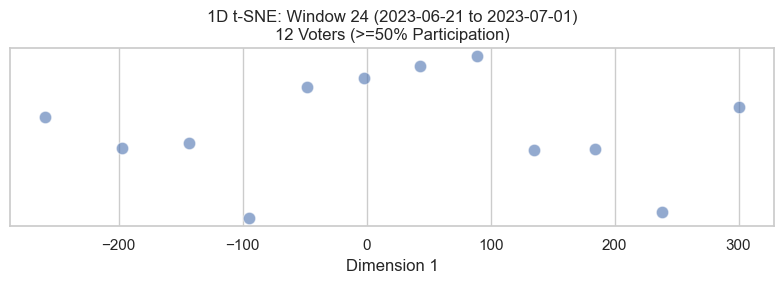

Done.
Processing Window 25... 

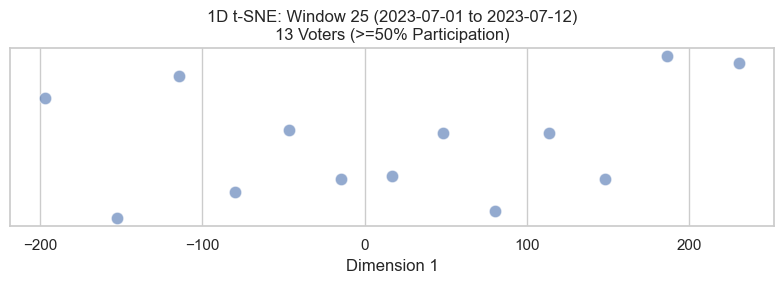

Done.
Processing Window 26... 

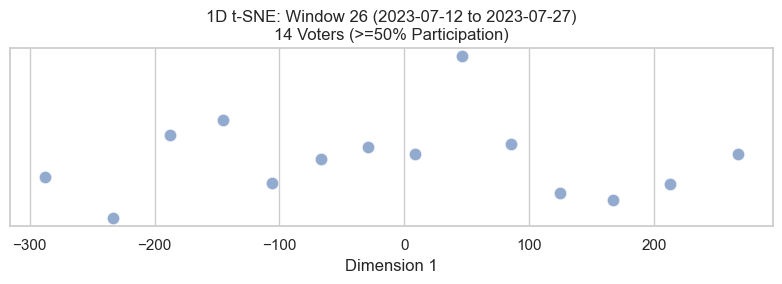

Done.
Processing Window 27... 

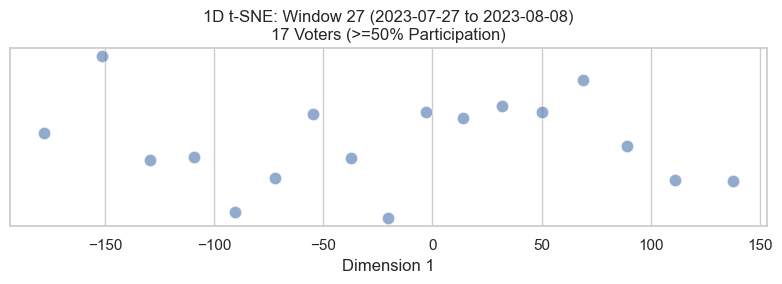

Done.
Processing Window 28... 

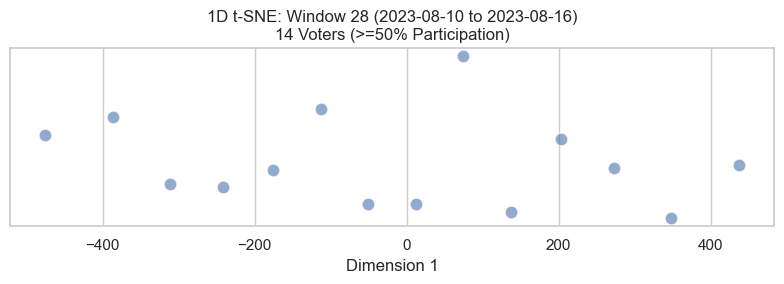

Done.
Processing Window 29... 

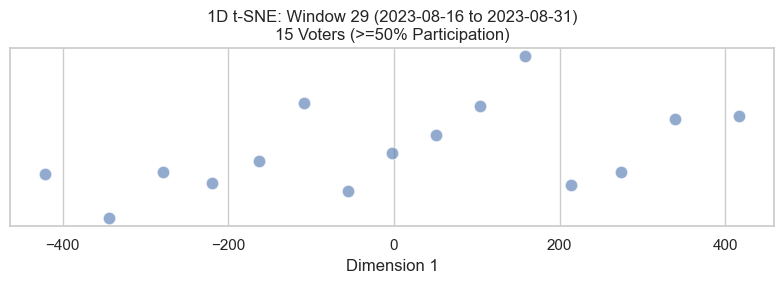

Done.
Processing Window 30... 

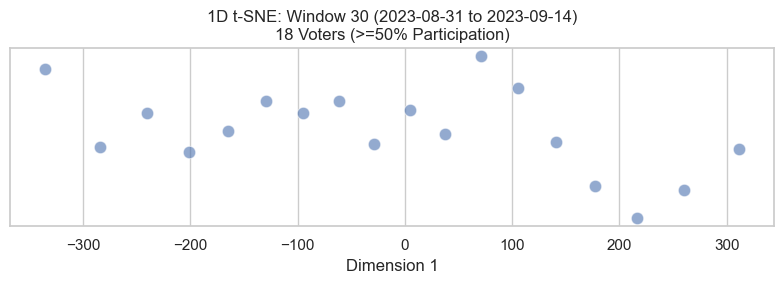

Done.
Processing Window 31... 

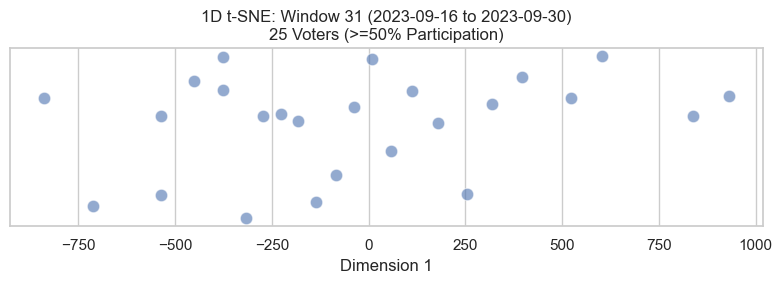

Done.
Processing Window 32... 

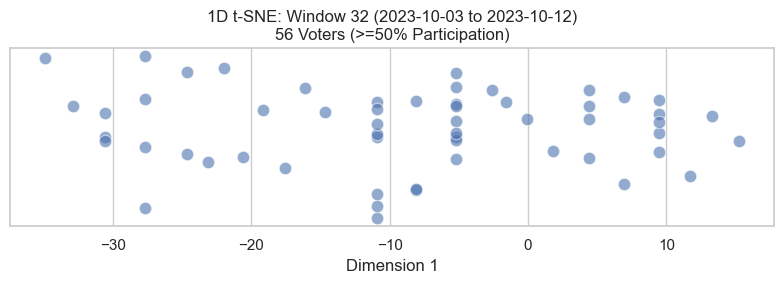

Done.
Processing Window 33... [[ 1  1  0  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  0  1  1  1  0  1  1  1]
 [ 1  1  1  1  1  1  0  0  0  0]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  0  1  1  1  0  1  1  1]
 [ 1  1  1  0  1  1 -1  1  1 -1]
 [ 1  1  1  0  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  0  0  0]
 [ 1  1  1  1  0  1  1  0  0  0]
 [ 1  1  1  1  1  1  1  0  0  0]
 [ 1  1  1  1  1  1  1  0  0  0]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 1  1  1  1  1  1  1  1  1  1]
 [ 0  1  1  1  1  1  1  0  0  0]
 [ 0  1  1  1  1  1  1  1  1  1]
 [ 0  1  1  0  1  1  1  0  0  0]
 [ 0  0  1  1  1  1  1  0  0  0]
 [ 0  0  1  1  1  1  1  0  0  0]]


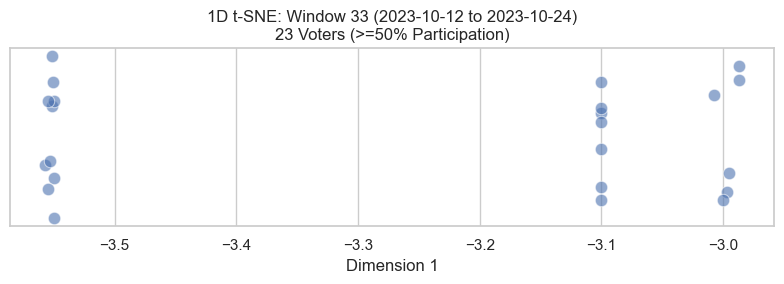

Done.
Processing Window 34... 

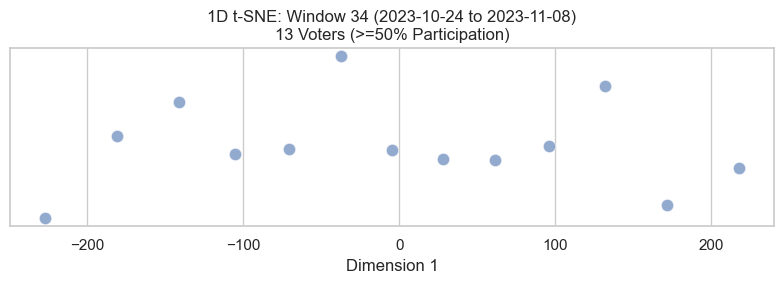

Done.
Processing Window 35... 

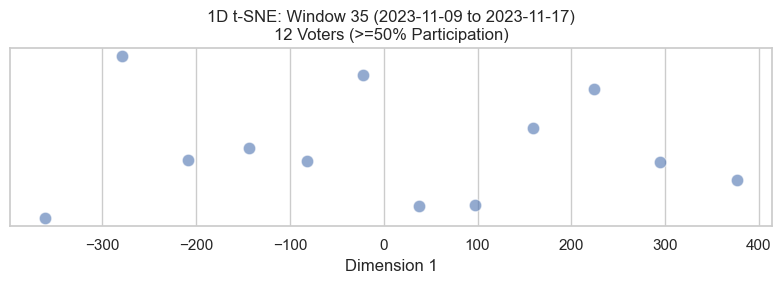

Done.
Processing Window 36... 

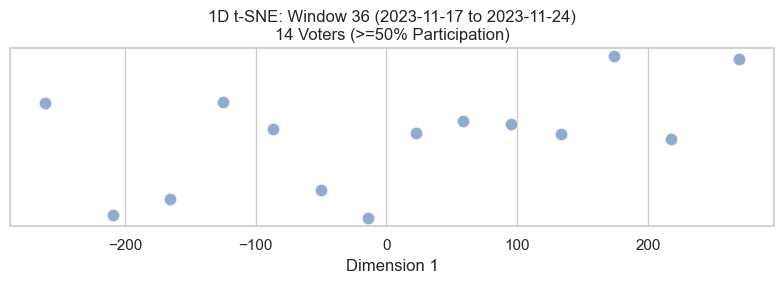

Done.
Processing Window 37... 

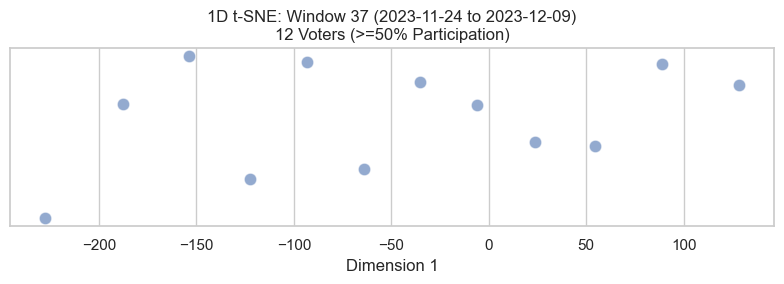

Done.
Processing Window 38... 

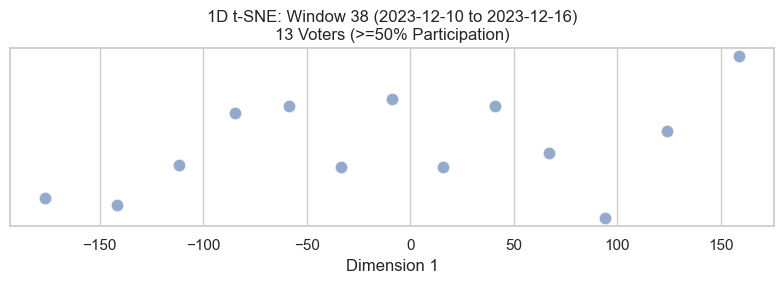

Done.


In [12]:
# Mapping for vectorization
vote_map = {'for': 1, 'against': -1, 'abstain': 0}

# Iterate through windows
for window_id, group in transactions_df.groupby('window_id'):
    # Skip incomplete windows
    if len(group) < window_size:
        continue
        
    print(f"Processing Window {window_id}...", end=" ")
    
    # 1. Identify voters with >= 50% support
    min_votes = window_size * 0.5
    
    voter_counts = {}
    for votes_list in group['votes']:
        proposal_voters = set(v['Voter_Address'] for v in votes_list)
        for v in proposal_voters:
            voter_counts[v] = voter_counts.get(v, 0) + 1
            
    active_voters = [v for v, c in voter_counts.items() if c >= min_votes]
    
    if len(active_voters) < 5:
        print(f"Skipping (Only {len(active_voters)} active voters).")
        continue

    # 2. Create Vectors
    voter_vectors = []
    for voter in active_voters:
        vector = []
        # Iterate through ALL proposals in this window
        for _, row in group.iterrows():
            vote_val = 0 # Default to 0 (abstain) if they didn't vote
            
            # Check if they voted on this specific proposal
            for v in row['votes']:
                if v['Voter_Address'] == voter:
                    vote_str = str(v['Vote_Type']).lower()
                    vote_val = vote_map.get(vote_str, 0)
                    break
            
            vector.append(vote_val)
        voter_vectors.append(vector)
        
    X = np.array(voter_vectors)
    if window_id == 33 or window_id == 8:
        print(X)
    # 3. Calculate t-SNE (1 Component)
    n_samples = len(active_voters)
    perp = min(30, n_samples - 1)
    if perp < 1: perp = 1
    
    tsne = TSNE(n_components=1, perplexity=perp, random_state=42, init='random', learning_rate='auto')
    
    try:
        X_embedded = tsne.fit_transform(X)
        
        # 4. Plot 1D Result
        plt.figure(figsize=(8, 3))
        
        # Add jitter for visibility
        y_jitter = np.random.normal(0, 0.02, size=len(X_embedded))
        
        sns.scatterplot(x=X_embedded[:,0], y=y_jitter, alpha=0.6, s=80)
        
        start_date = group['Proposal_Start_Time'].min().date()
        end_date = group['Proposal_Start_Time'].max().date()
        
        plt.title(f"1D t-SNE: Window {window_id} ({start_date} to {end_date})\n{n_samples} Voters (>=50% Participation)")
        plt.xlabel("Dimension 1")
        plt.yticks([])
        plt.tight_layout()
        plt.show()
        print("Done.")
        
    except Exception as e:
        print(f"Error plotting: {e}")
        
    gc.collect()

Plotting cumulative votes for the first 5 proposals...
Proposal ID: 0


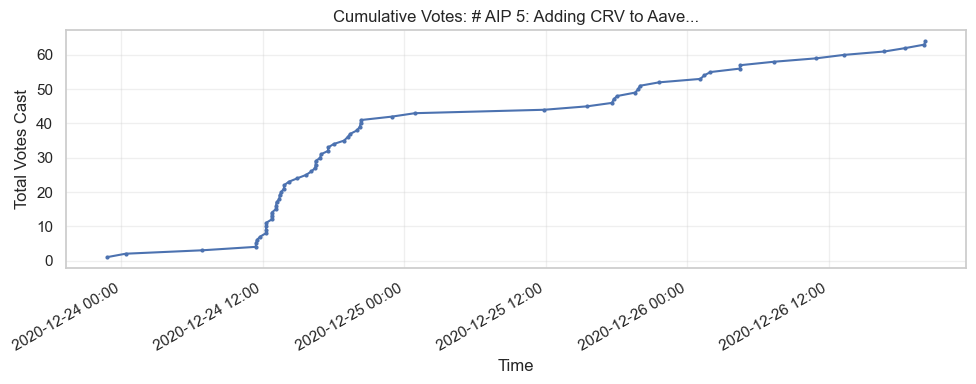

Proposal ID: 1


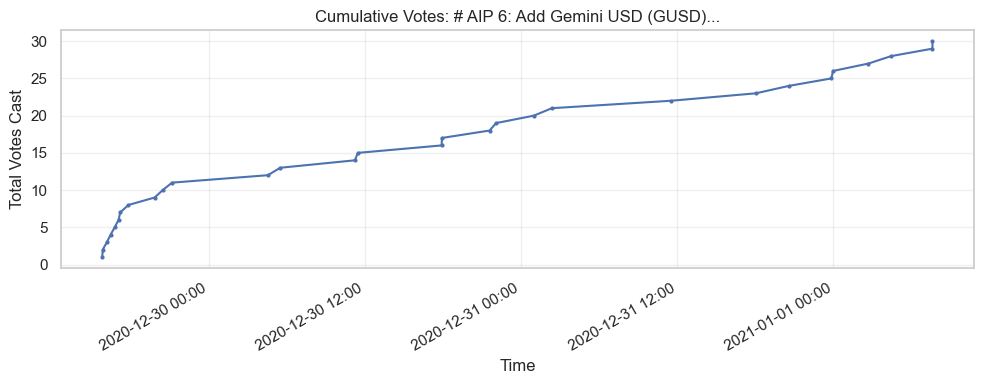

Proposal ID: 2


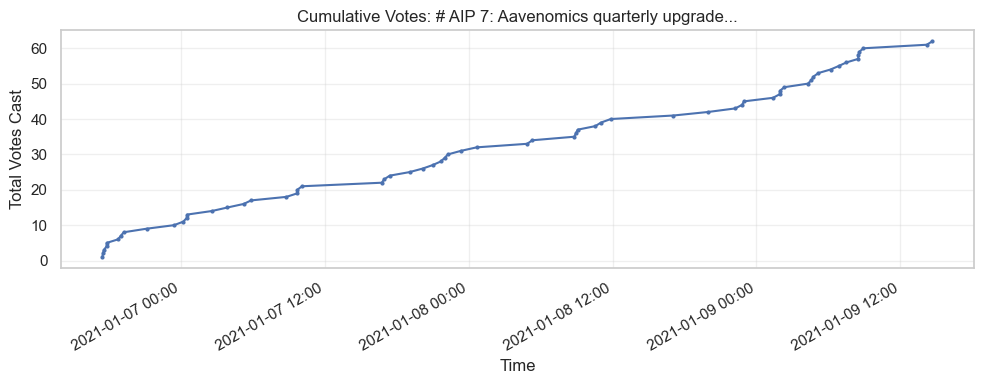

Proposal ID: 3


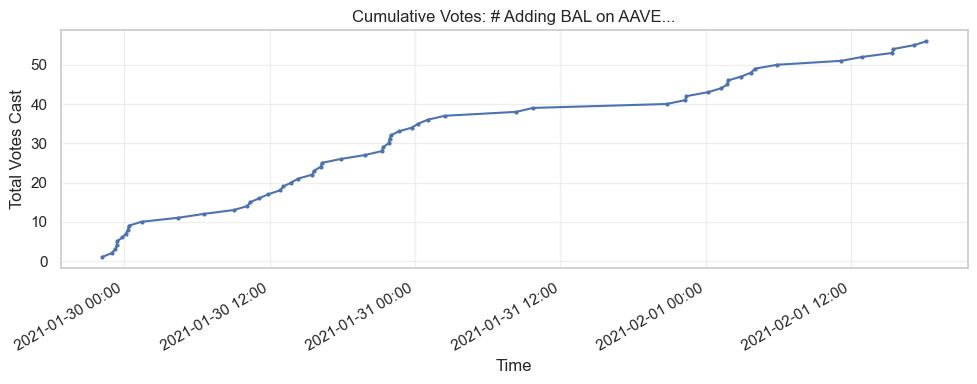

Proposal ID: 4


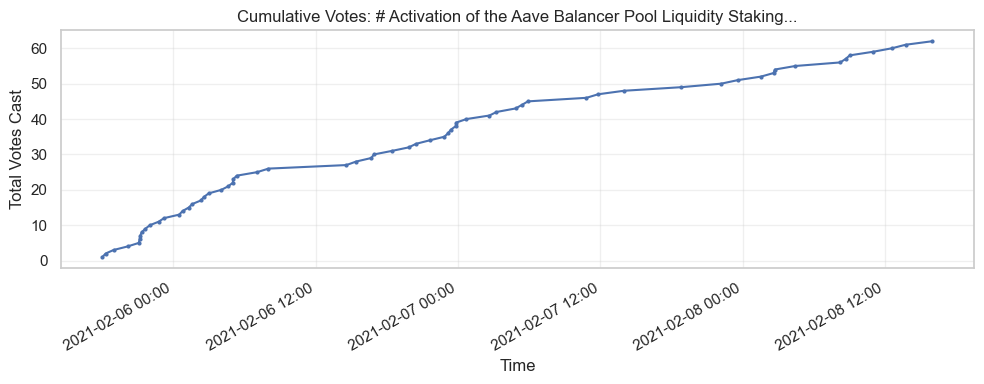

Proposal ID: 5


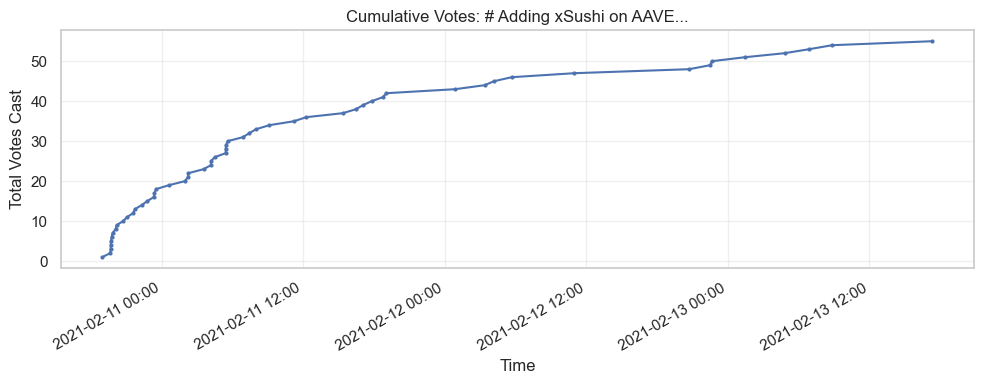

Proposal ID: 6


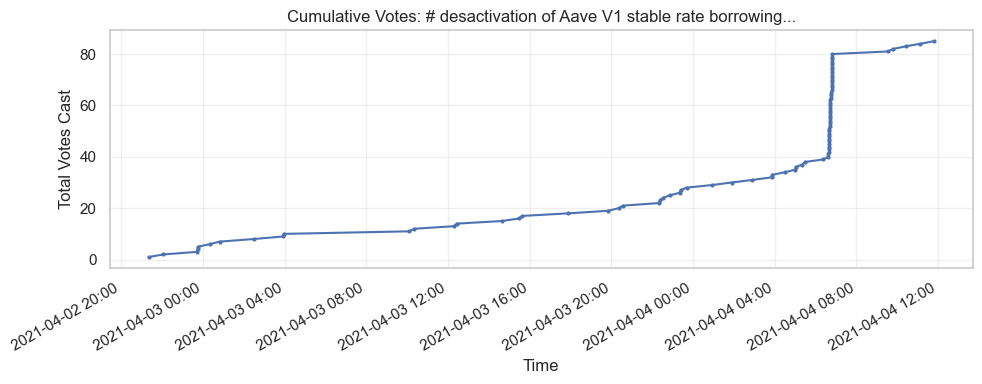

Proposal ID: 7


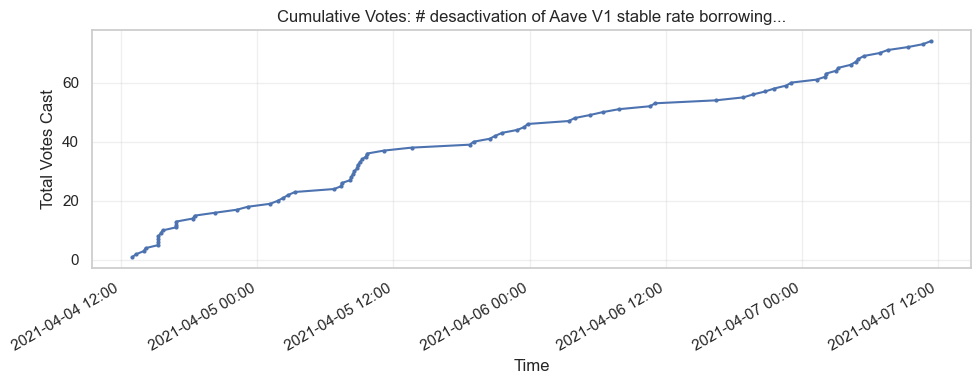

Proposal ID: 8


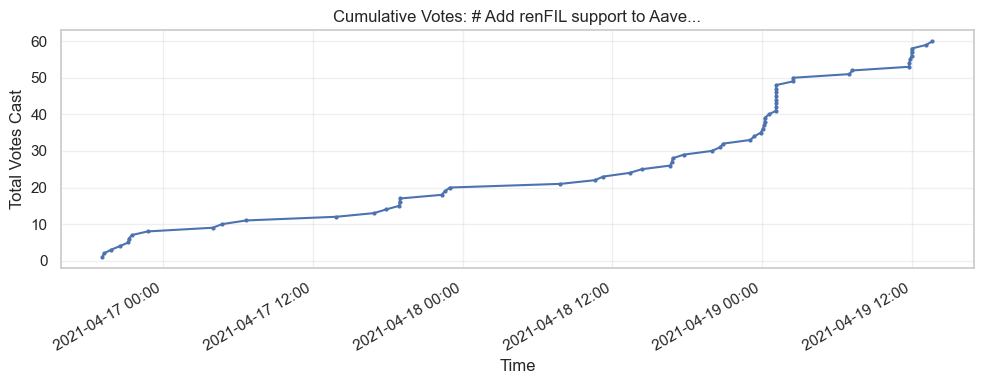

Proposal ID: 9


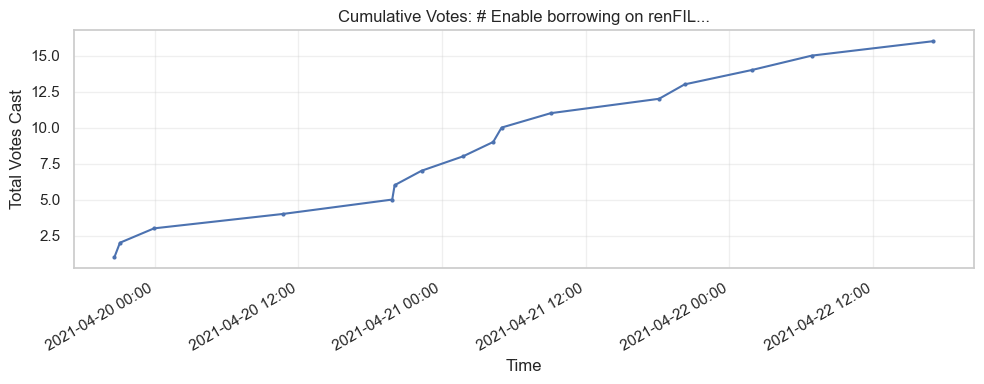

Proposal ID: 10


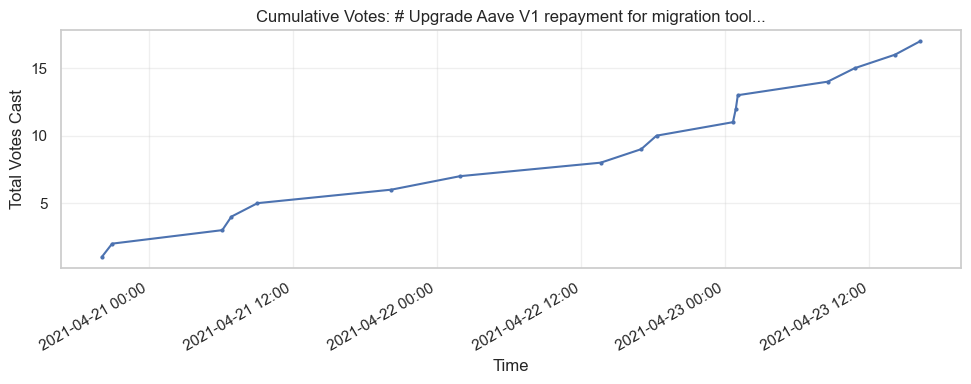

Proposal ID: 11


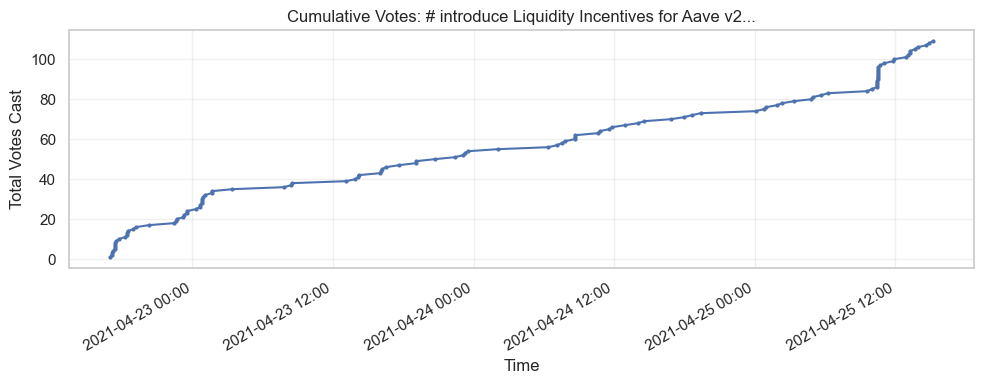

Proposal ID: 12


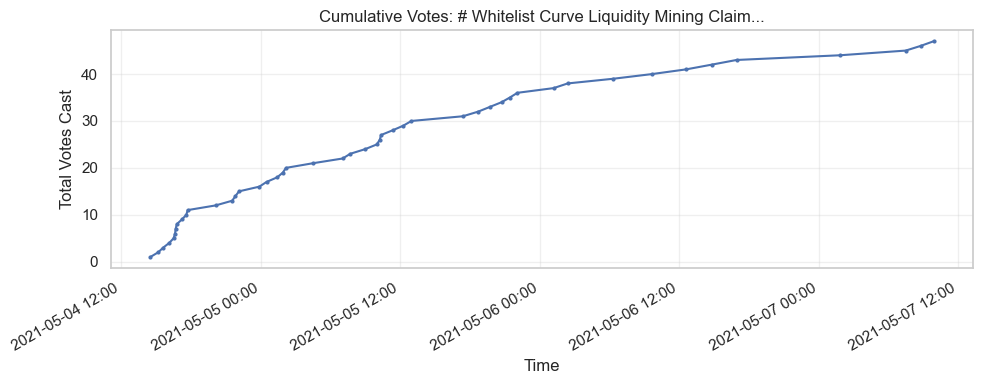

Proposal ID: 13


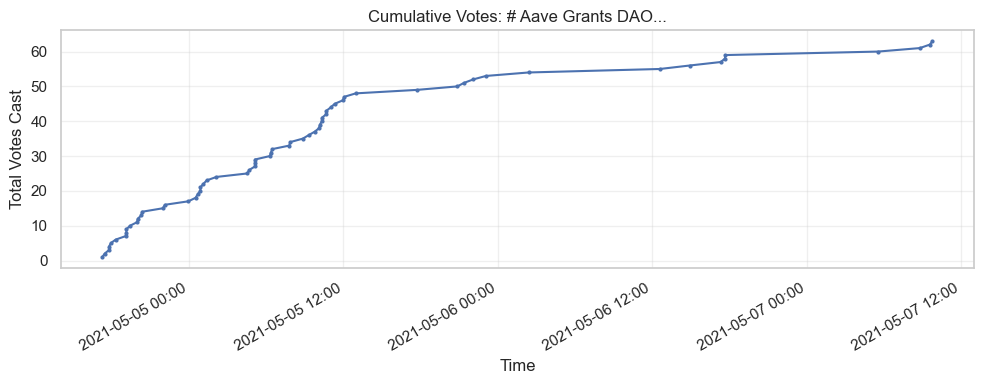

Proposal ID: 14


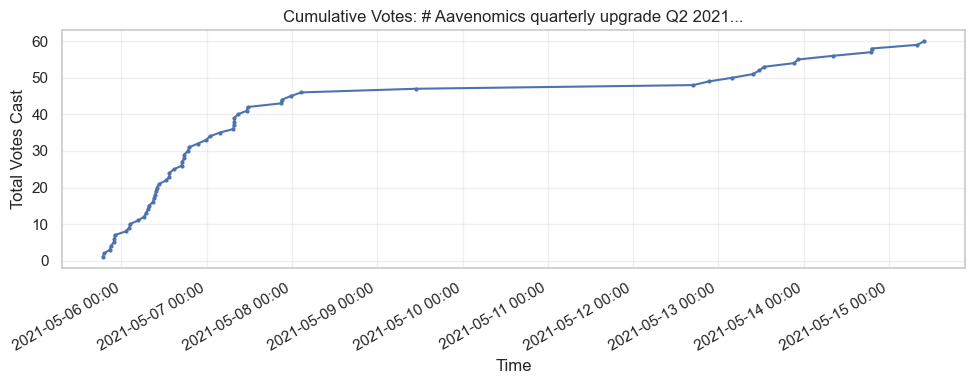

Proposal ID: 15


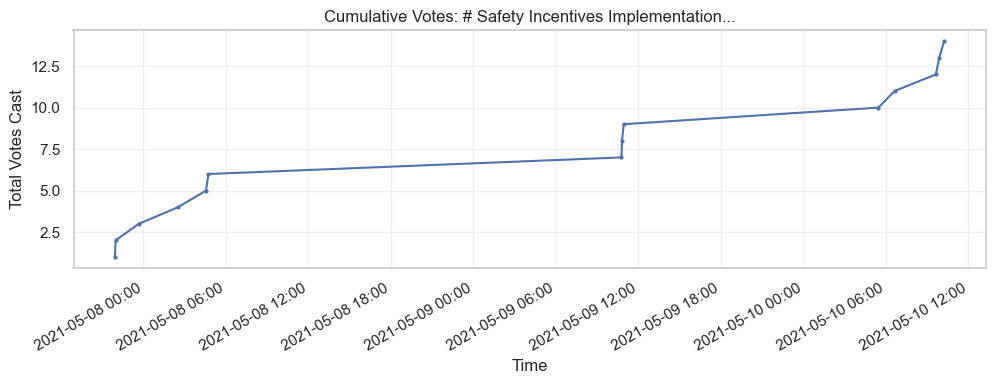

Proposal ID: 16


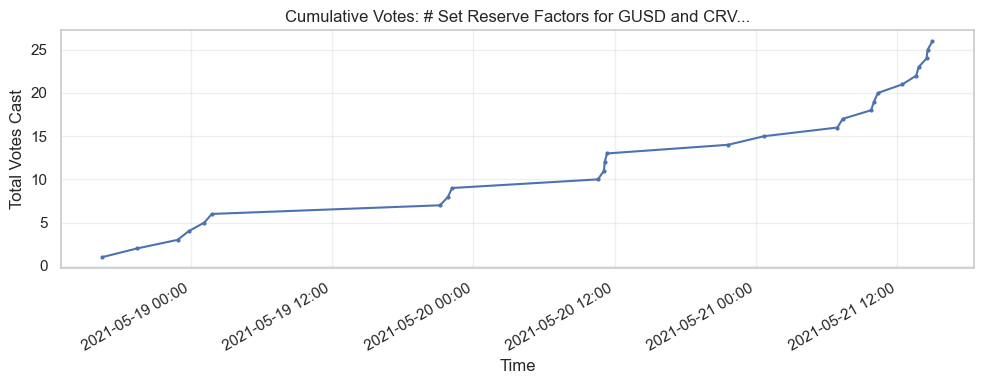

Proposal ID: 17


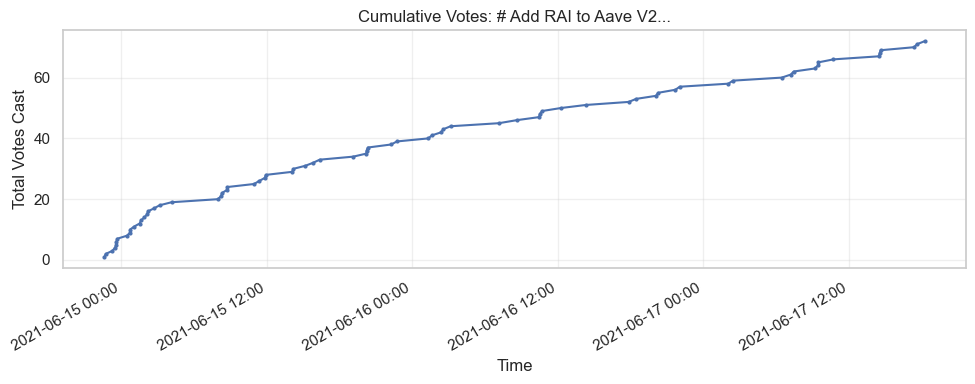

Proposal ID: 18


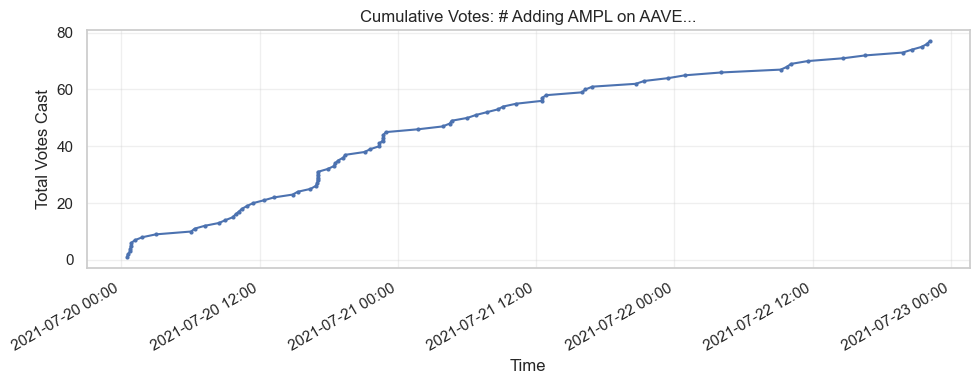

Proposal ID: 19


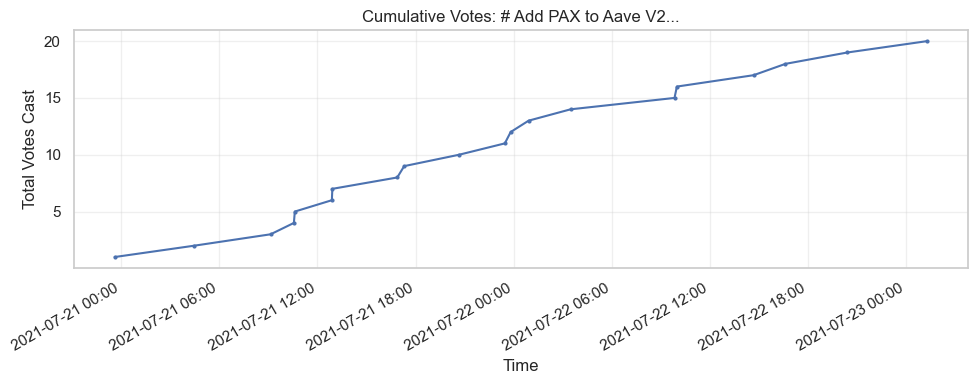

Proposal ID: 21


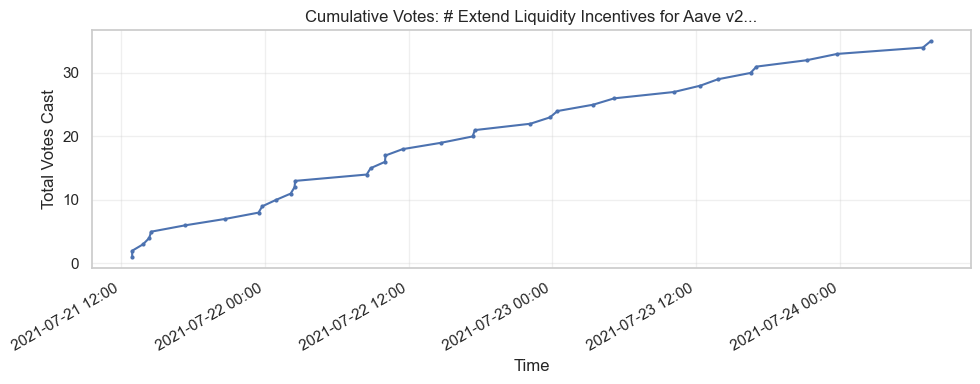

Proposal ID: 22


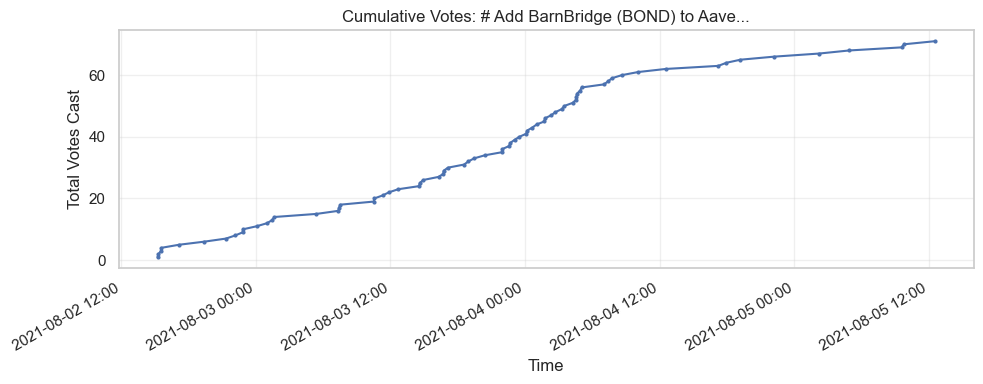

Proposal ID: 23


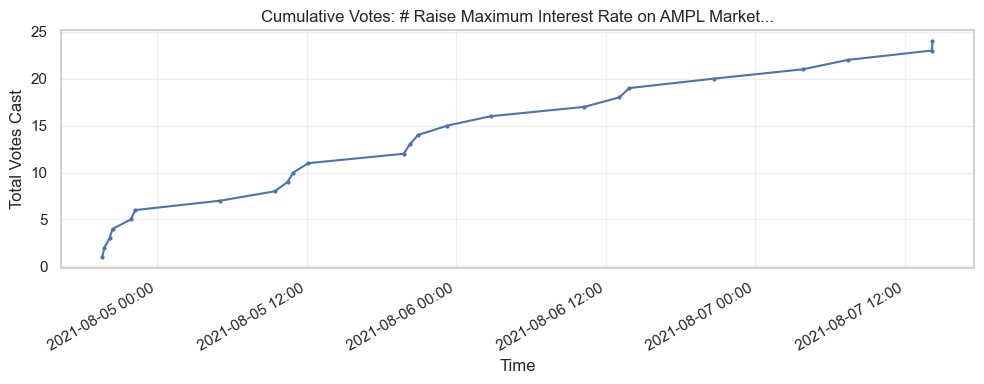

Proposal ID: 24


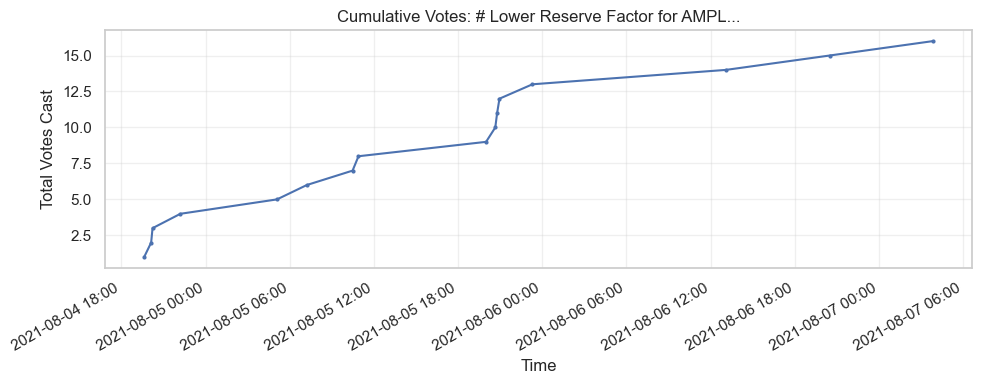

Proposal ID: 25


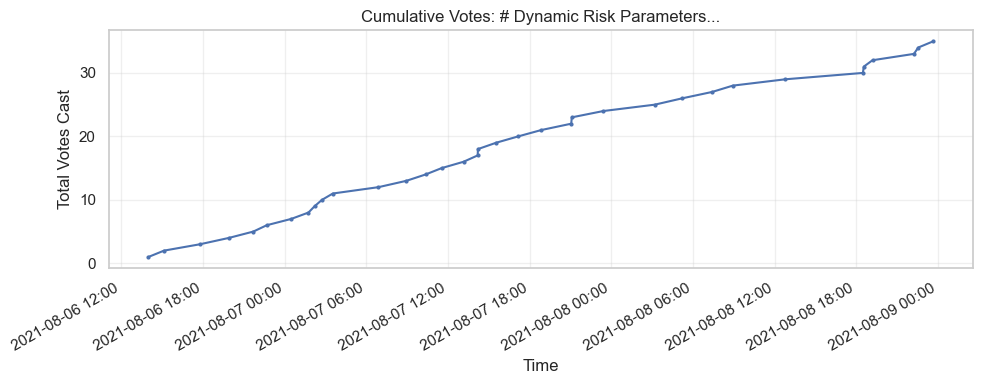

Proposal ID: 26


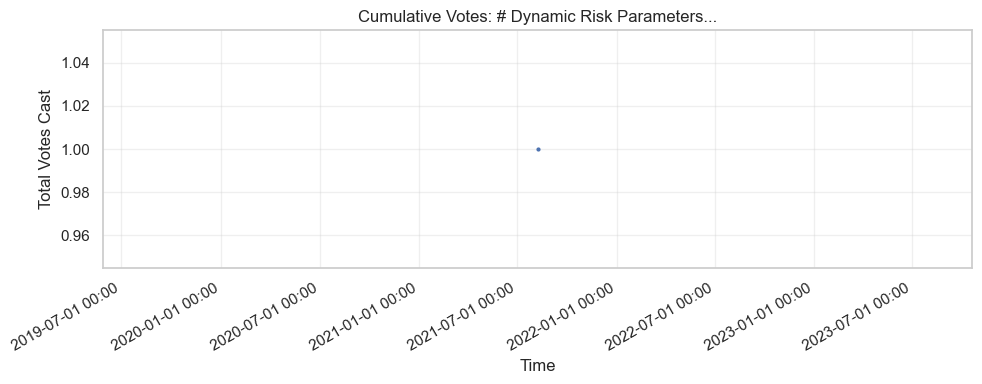

Proposal ID: 27


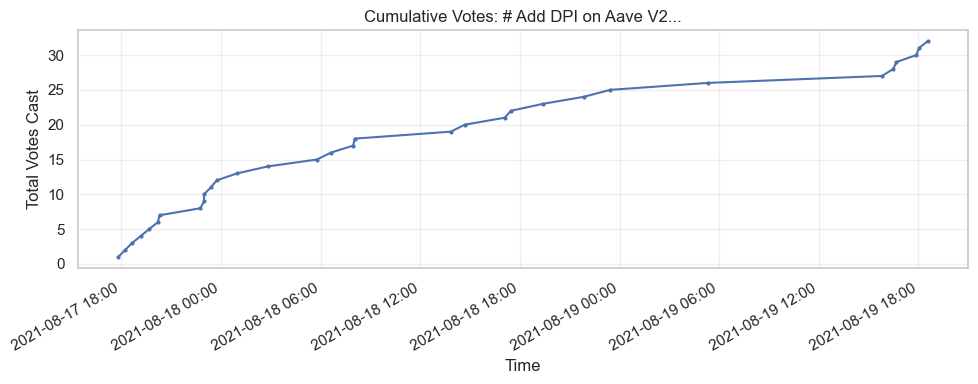

Proposal ID: 28


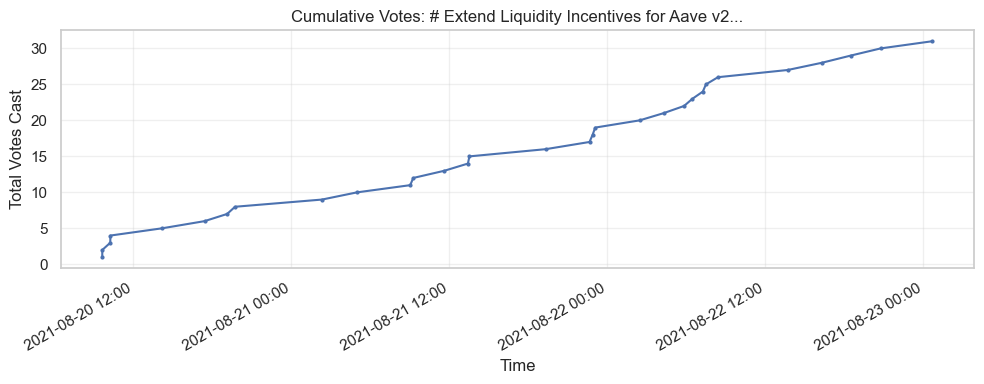

Proposal ID: 29


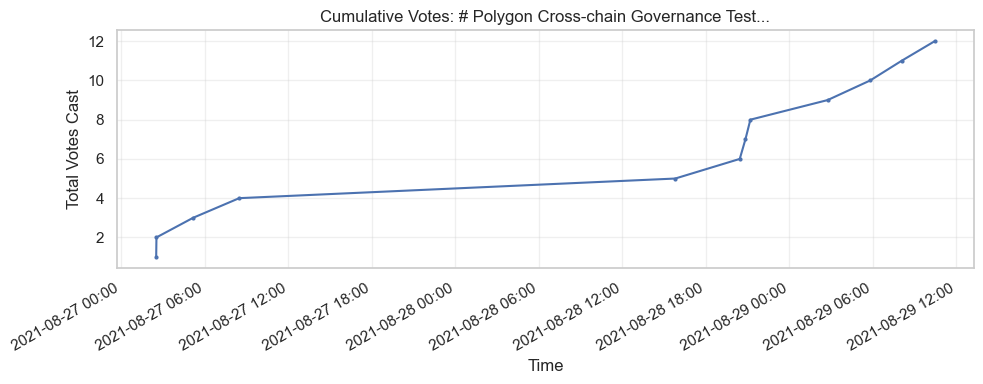

Proposal ID: 30


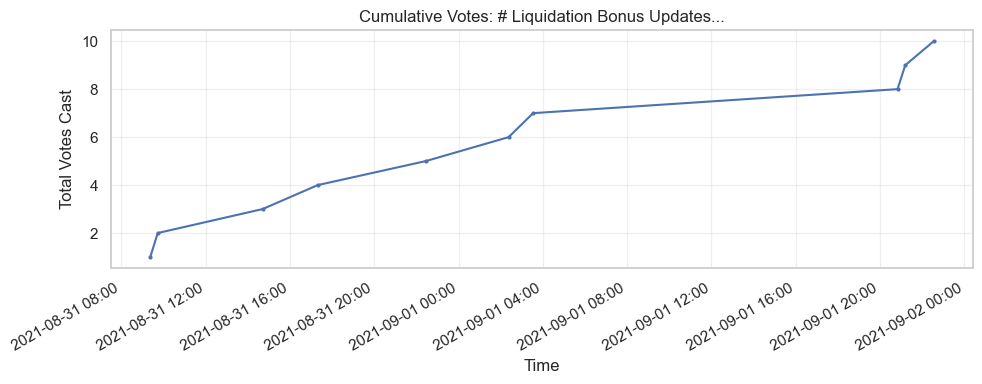

In [15]:
import matplotlib.dates as mdates

def plot_proposal_cumulative_votes(row):
    votes = row['votes']
    if not votes:
        return
    
    # Extract timestamps and sort them
    timestamps = sorted([pd.to_datetime(v['Timestamp']) for v in votes])
    
    # Create cumulative count (1, 2, 3, ... N)
    counts = range(1, len(timestamps) + 1)
    
    plt.figure(figsize=(10, 4))
    plt.plot(timestamps, counts, marker='.', linestyle='-', markersize=4)
    
    plt.title(f"Cumulative Votes: {str(row['Proposal_Title'])[:60]}...")
    plt.xlabel("Time")
    plt.ylabel("Total Votes Cast")
    plt.grid(True, alpha=0.3)
    
    # Format x-axis nicely
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    plt.show()

# Example: Plot for the first 5 proposals
print("Plotting cumulative votes for the first 5 proposals...")
for i, row in transactions_df.head(30).iterrows():
    print(f"Proposal ID: {row['Onchain_ID']}")
    plot_proposal_cumulative_votes(row)

In [ ]:
# I have transactions_df, want to use apriori to find patterns in the data on the voters

# filter support of 50% and confidence of 80%

# then i want to make graph of the patterns where the nodes are the voters and the edges are the confidence value

# plot the graph

In [48]:
# You might need to install mlxtend if not already installed
# !pip install mlxtend networkx

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx

# 1. Prepare Transactions
# We need a list of lists, where each inner list contains the items (voter_voteType) for a transaction
dataset = []
for _, row in transactions_df.iterrows():
    # Extract the 'vote_item' (e.g., "0x123..._FOR") from the votes list
    transaction_items = [v['vote_item'] for v in row['votes']]
    if transaction_items:
        dataset.append(transaction_items)

print(f"Processing {len(dataset)} transactions for Apriori...")

# 2. One-Hot Encode
te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# 3. Run Apriori
# min_support=0.5 means the pattern must appear in at least 50% of ALL proposals
frequent_itemsets = apriori(df_encoded, min_support=0.2, use_colnames=True)

print(f"Found {len(frequent_itemsets)} frequent itemsets.")

# 4. Generate Association Rules
# min_threshold=0.8 means 80% confidence
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.8)

# Filter for useful rules (e.g., length 1 to 1 for simple graph edges)
# We only want pairwise rules: {A} -> {B}
rules['antecedent_len'] = rules['antecedents'].apply(lambda x: len(x))
rules['consequent_len'] = rules['consequents'].apply(lambda x: len(x))

pairwise_rules = rules[ (rules['antecedent_len'] == 1) & (rules['consequent_len'] == 1) ].copy()

print(f"Found {len(pairwise_rules)} pairwise rules with >80% confidence.")
pairwise_rules.head()

Processing 397 transactions for Apriori...
Found 473 frequent itemsets.
Found 61 pairwise rules with >80% confidence.


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent_len,consequent_len
0,(0x1855f41B8A86e701E33199DE7C25d3e3830698ba_FOR),(0x13BDaE8c5F0fC40231F0E6A4ad70196F59138548_FOR),0.488665,0.506297,0.392947,0.804124,1.588244,1.0,0.145537,2.520483,0.724327,0.652720,0.603251,0.790122,1,1
1,(0x2cc1ADE245020FC5AAE66Ad443e1F66e01c54Df1_FOR),(0x13BDaE8c5F0fC40231F0E6A4ad70196F59138548_FOR),0.269521,0.506297,0.226700,0.841121,1.661320,1.0,0.090242,3.107423,0.544943,0.412844,0.678190,0.644441,1,1
2,(0x13BDaE8c5F0fC40231F0E6A4ad70196F59138548_FOR),(0x329c54289Ff5D6B7b7daE13592C6B1EDA1543eD4_FOR),0.506297,0.700252,0.453401,0.895522,1.278858,1.0,0.098865,2.869018,0.441667,0.602007,0.651449,0.771502,1,1
3,(0x57ab7ee15cE5ECacB1aB84EE42D5A9d0d8112922_FOR),(0x13BDaE8c5F0fC40231F0E6A4ad70196F59138548_FOR),0.246851,0.506297,0.216625,0.877551,1.733272,1.0,0.091645,4.031906,0.561717,0.403756,0.751978,0.652706,1,1
4,(0x8659D0BB123Da6D16D9394C7838BA286c2207d0E_FOR),(0x13BDaE8c5F0fC40231F0E6A4ad70196F59138548_FOR),0.234257,0.506297,0.206549,0.881720,1.741508,1.0,0.087945,4.174033,0.556041,0.386792,0.760424,0.644840,1,1


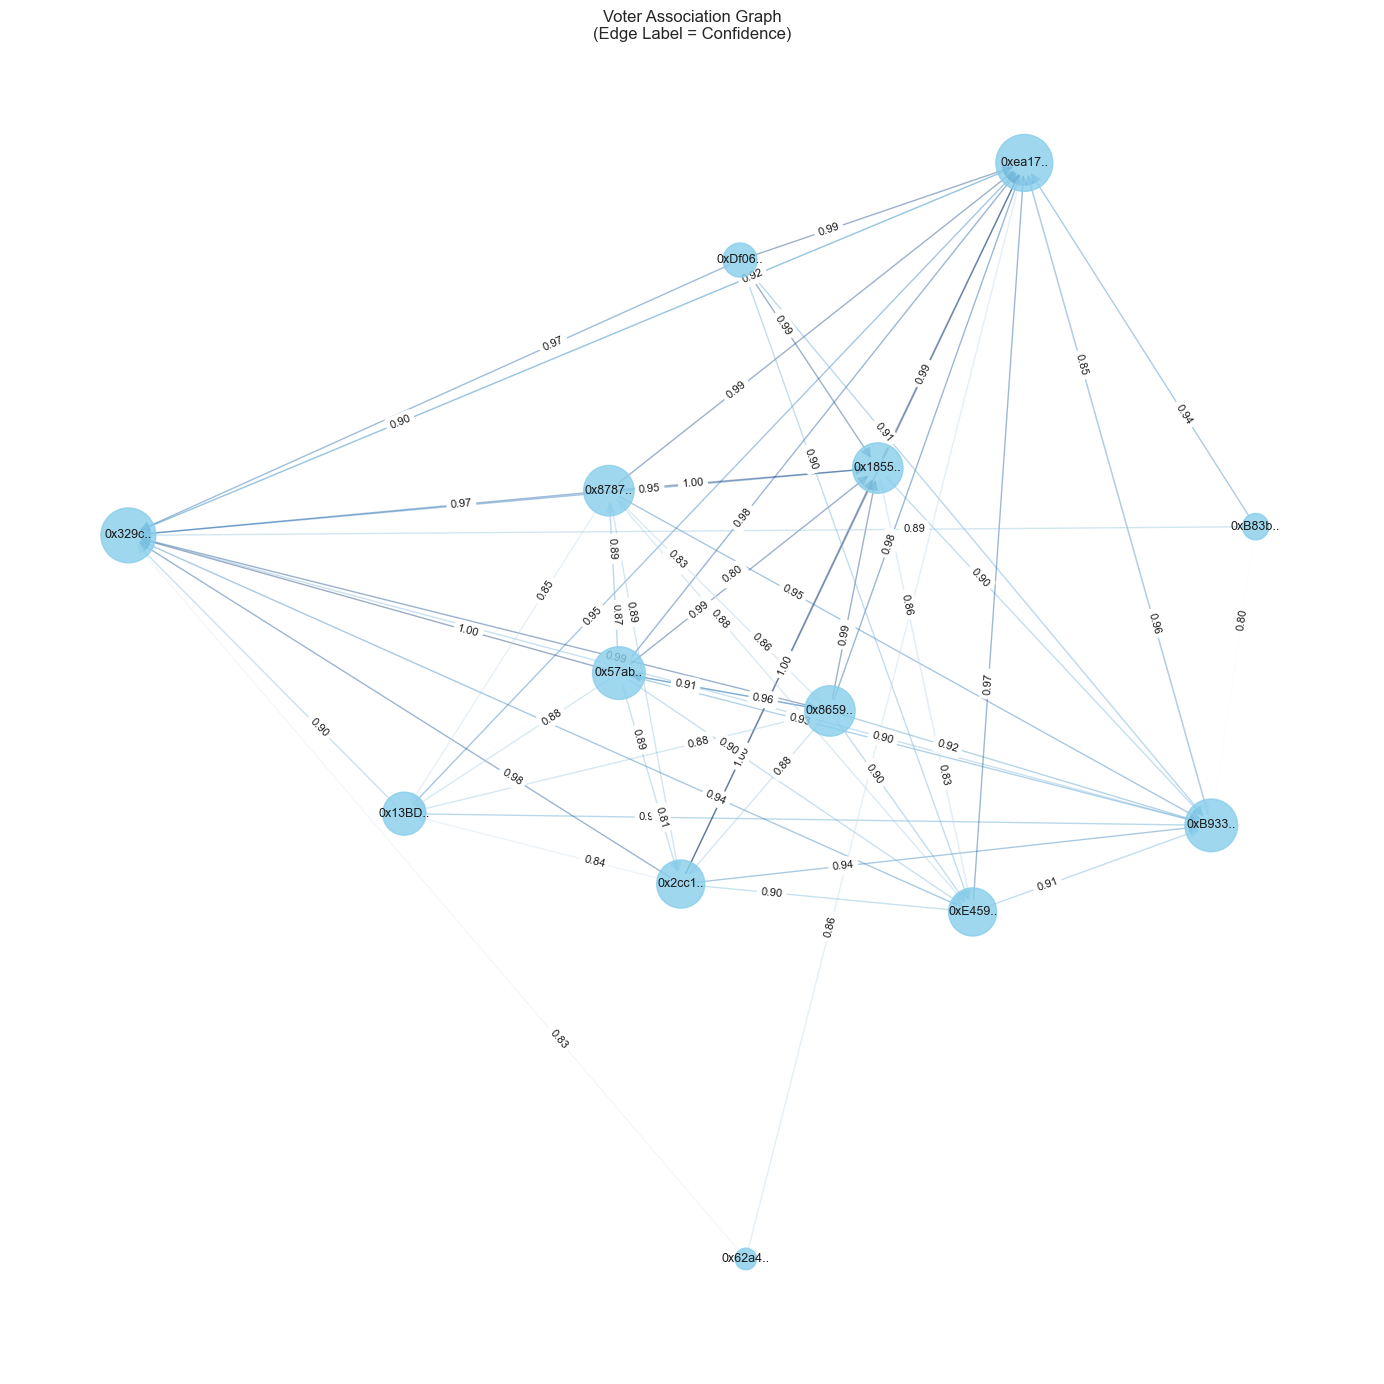

In [49]:
# Create Graph
G = nx.DiGraph()

def clean_node_label(node_set):
    return list(node_set)[0]

for _, row in pairwise_rules.iterrows():
    u = clean_node_label(row['antecedents'])
    v = clean_node_label(row['consequents'])
    weight = row['confidence']
    G.add_edge(u, v, weight=weight)

# Plotting
plt.figure(figsize=(14, 14))

# Layout
pos = nx.spring_layout(G, k=0.6, iterations=50)

# Draw Nodes
node_sizes = [G.degree(n) * 120 for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.8)

# Draw Edges
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.4, edge_color=weights, edge_cmap=plt.cm.Blues, arrowsize=15)

# Draw Edge Labels (Confidence)
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.3)

# Draw Node Labels (Address Only)
labels = {}
for node in G.nodes():
    # Node is "ADDRESS_VOTETYPE"
    # We split by '_' and take the first part (Address)
    parts = node.split('_')
    addr = parts[0]
    # Shorten for readability
    labels[node] = f"{addr[:6]}.."

nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

plt.title("Voter Association Graph\n(Edge Label = Confidence)")
plt.axis('off')
plt.tight_layout()
plt.show()

In [50]:
# Calculate Centrality Metrics
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000, weight='weight')
in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)

# Combine into a DataFrame
centrality_df = pd.DataFrame({
    'Eigenvector': eigenvector_centrality,
    'In_Degree': in_degree_centrality,
    'Out_Degree': out_degree_centrality
})

# Sort by Eigenvector Centrality to see the most influential nodes
centrality_df = centrality_df.sort_values('Out_Degree', ascending=False)

# Display the top 20 most central voters
print("Top 20 Voters by Centrality:")
centrality_df.head(2000)

Top 20 Voters by Centrality:


,Eigenvector,In_Degree,Out_Degree
0x57ab7ee15cE5ECacB1aB84EE42D5A9d0d8112922_FOR,3.541662e-02,0.250000,0.750000
0x8659D0BB123Da6D16D9394C7838BA286c2207d0E_FOR,2.498159e-02,0.166667,0.750000
0x8787FC2De4De95c53e5E3a4e5459247D9773ea52_FOR,2.471880e-02,0.166667,0.750000
0x2cc1ADE245020FC5AAE66Ad443e1F66e01c54Df1_FOR,3.567789e-02,0.250000,0.583333
0x1855f41B8A86e701E33199DE7C25d3e3830698ba_FOR,9.156831e-02,0.500000,0.416667
0xDf06A761D286C0ae835173236E1f12f1379E4977_FOR,5.540579e-22,0.000000,0.416667
0xE4594A66d9507fFc0d4335CC240BD61C1173E666_FOR,8.823440e-02,0.500000,0.333333
0x13BDaE8c5F0fC40231F0E6A4ad70196F59138548_FOR,8.421199e-02,0.416667,0.250000
0xB83b3e9C8E3393889Afb272D354A7a3Bd1Fbcf5C_FOR,5.540579e-22,0.000000,0.250000
0xB933AEe47C438f22DE0747D57fc239FE37878Dd1_FOR,4.210994e-01,0.833333,0.166667


Tracking 10 voters with lowest Eigenvector centrality.
Searching for proposals with low centrality votes...


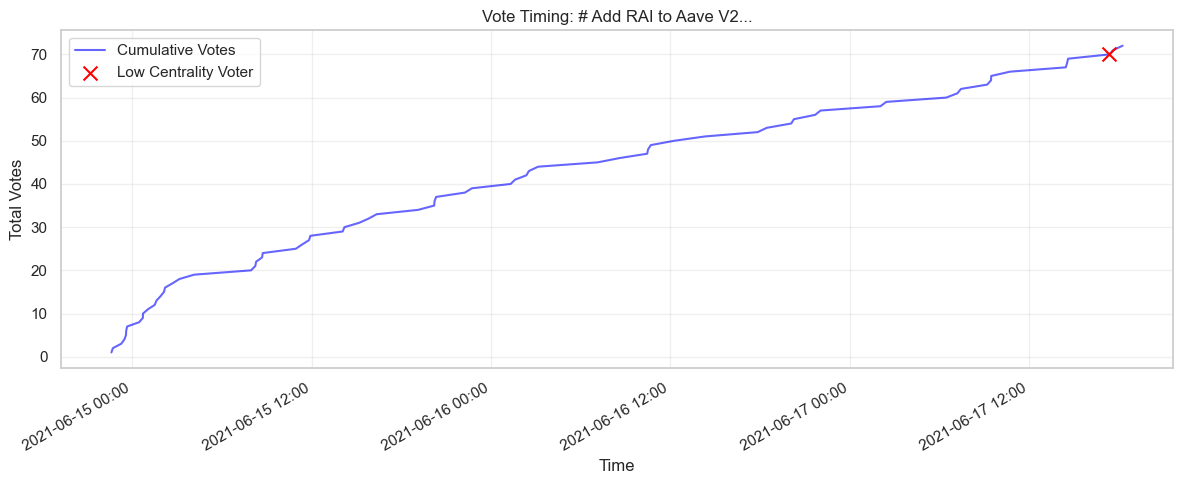

Found match: Proposal ID 17


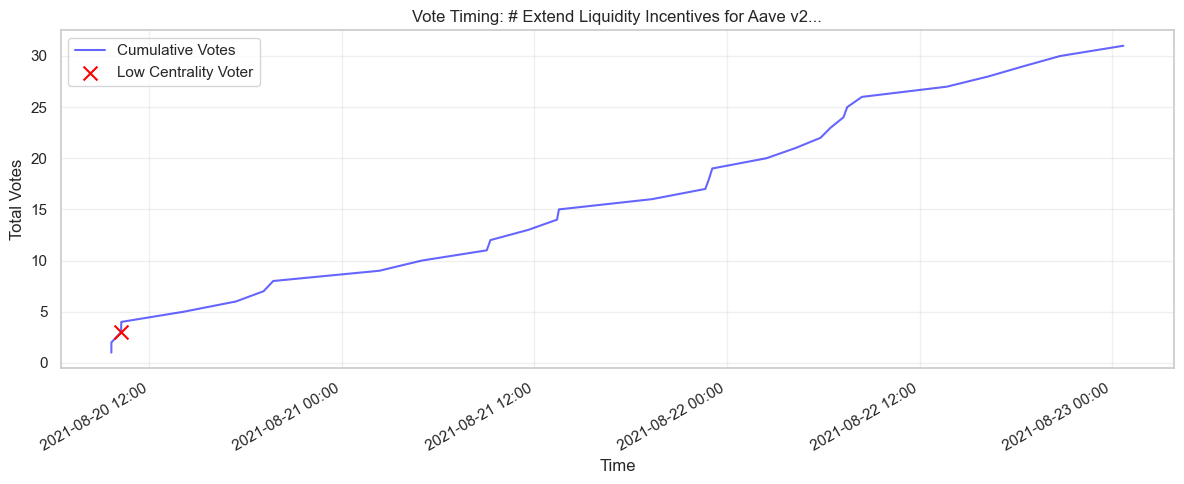

Found match: Proposal ID 28


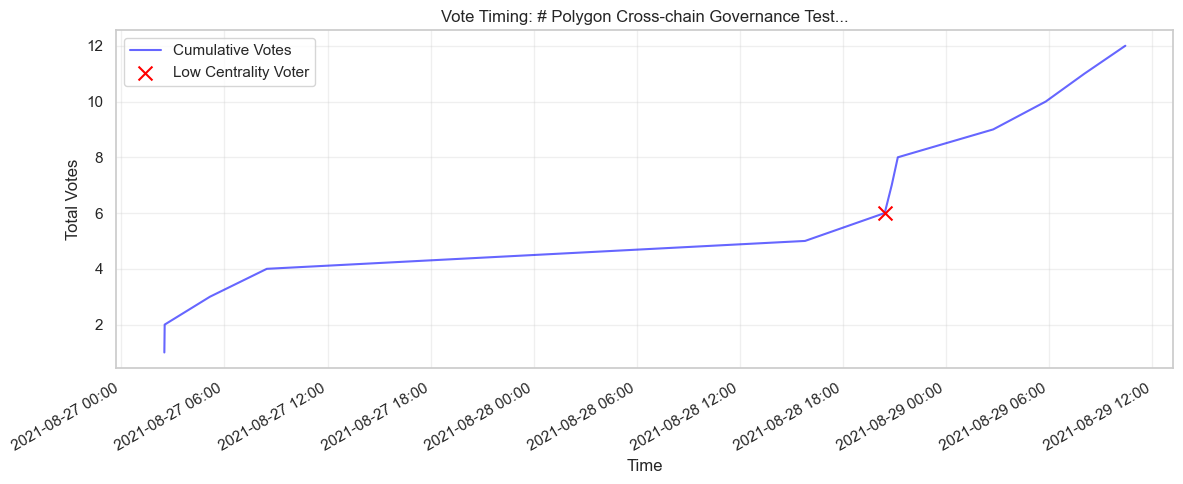

Found match: Proposal ID 29


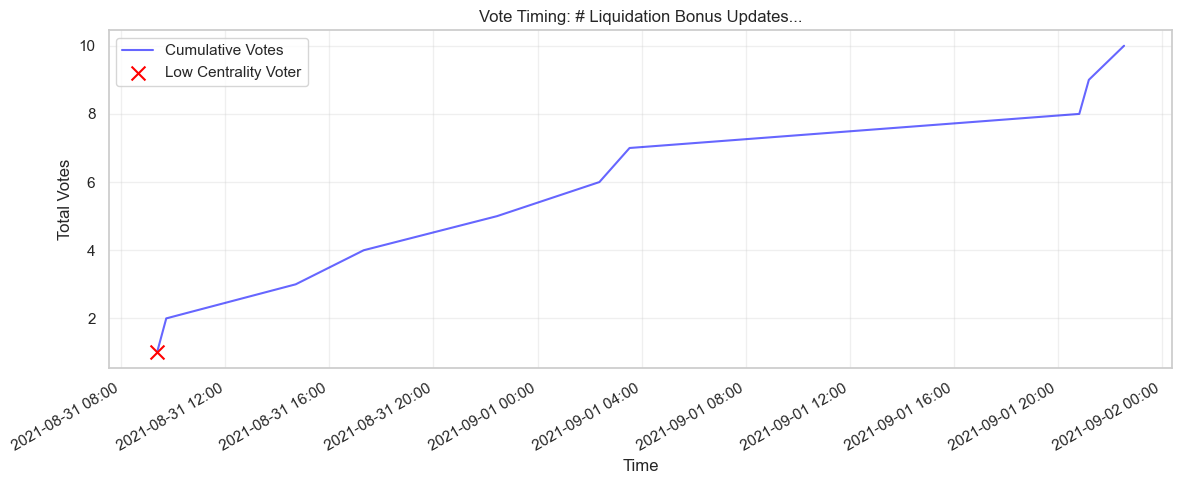

Found match: Proposal ID 30


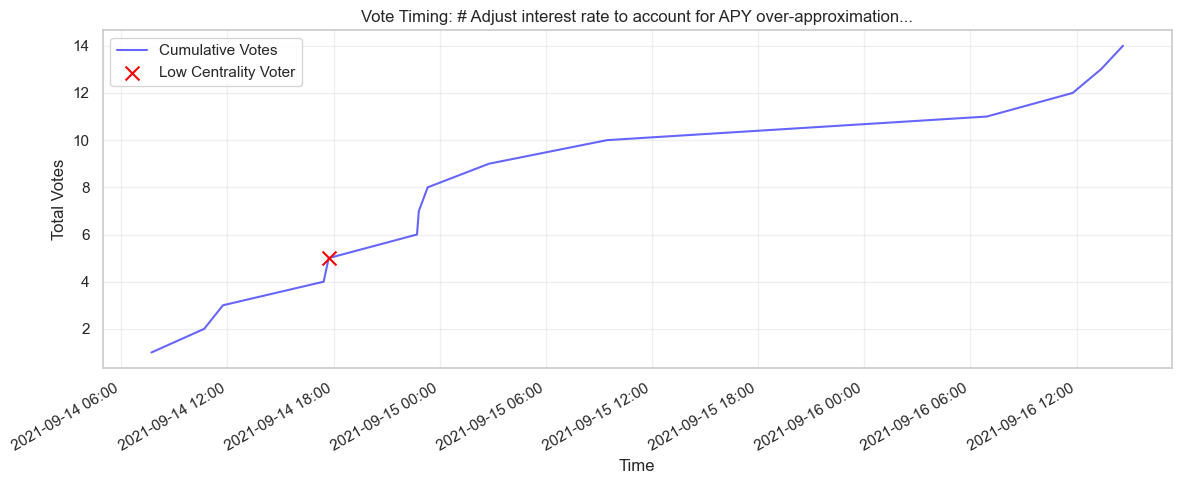

Found match: Proposal ID 36


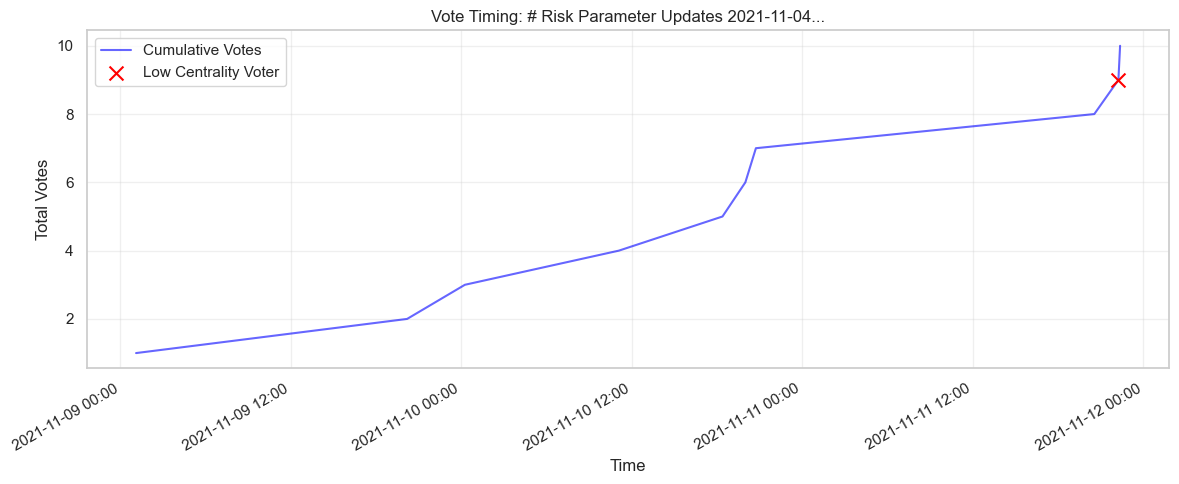

Found match: Proposal ID 45


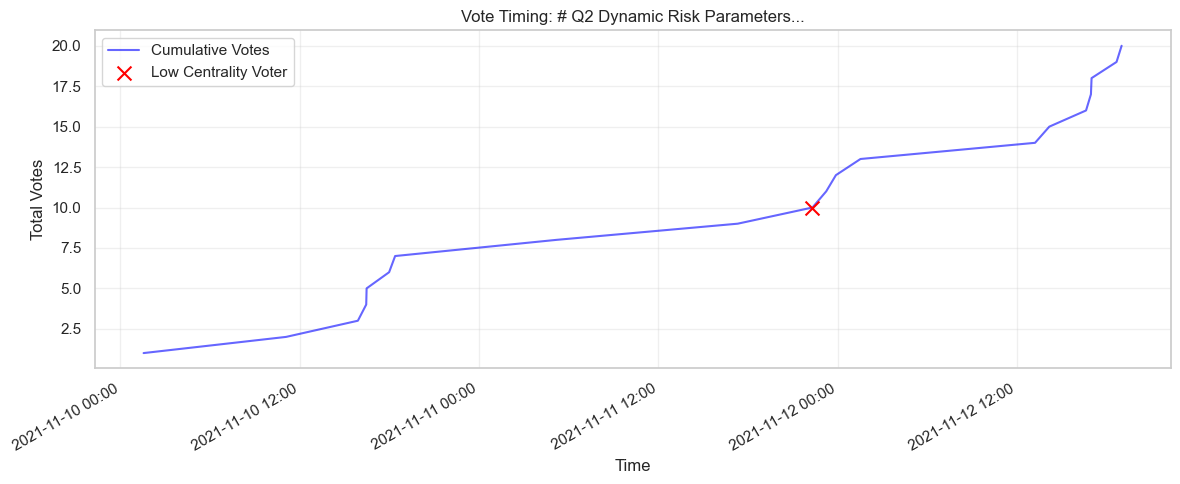

Found match: Proposal ID 46


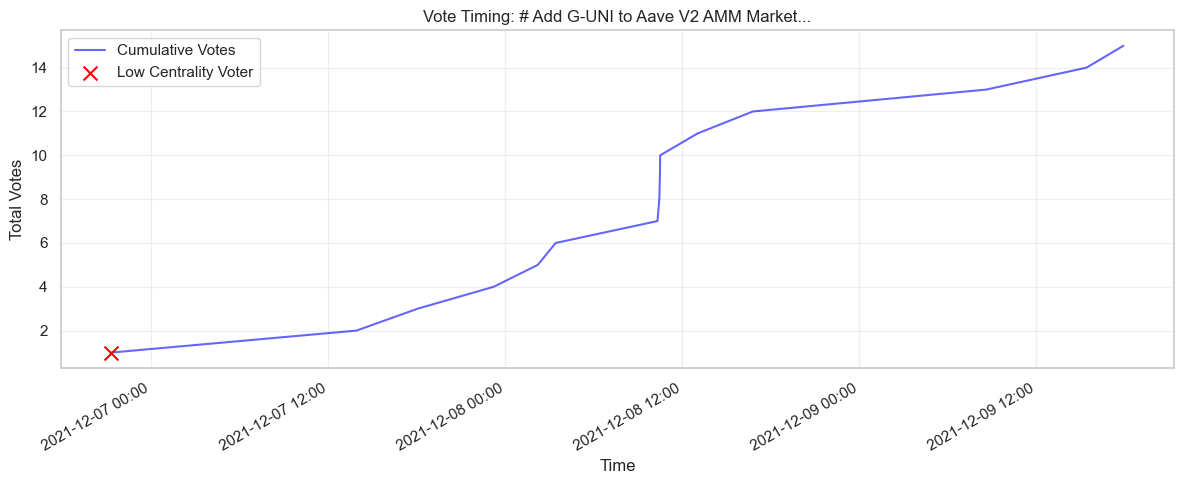

Found match: Proposal ID 51


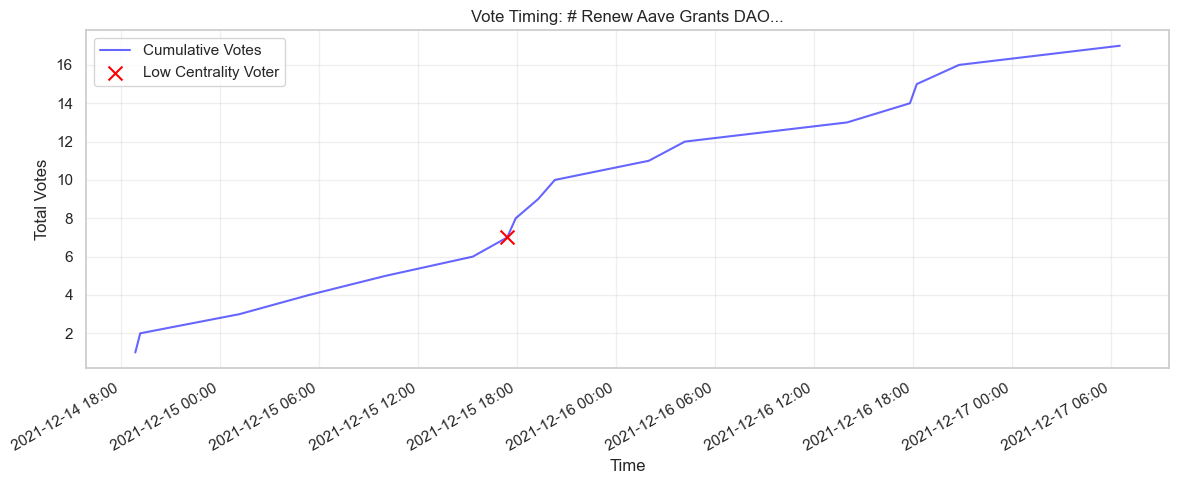

Found match: Proposal ID 52


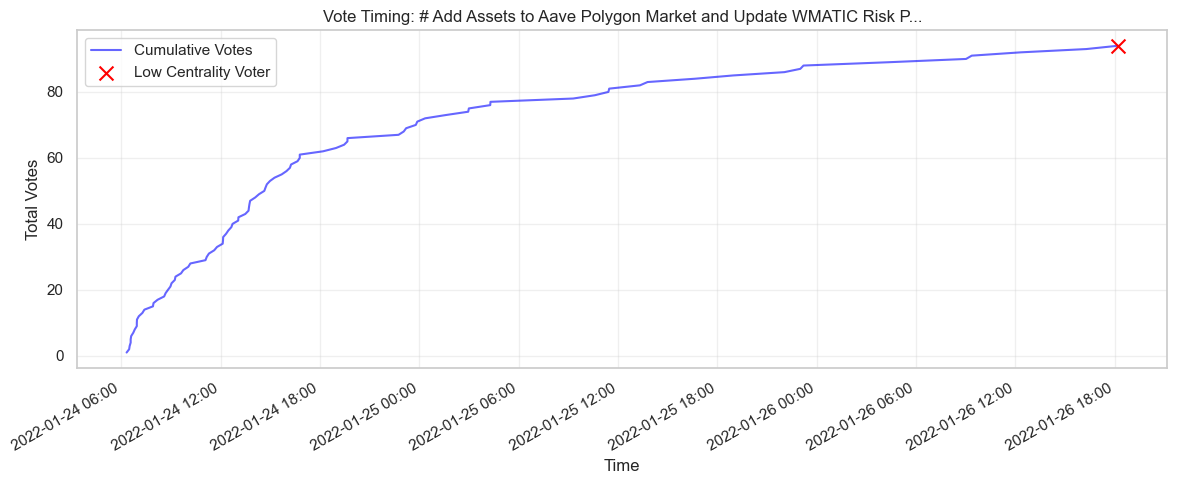

Found match: Proposal ID 56


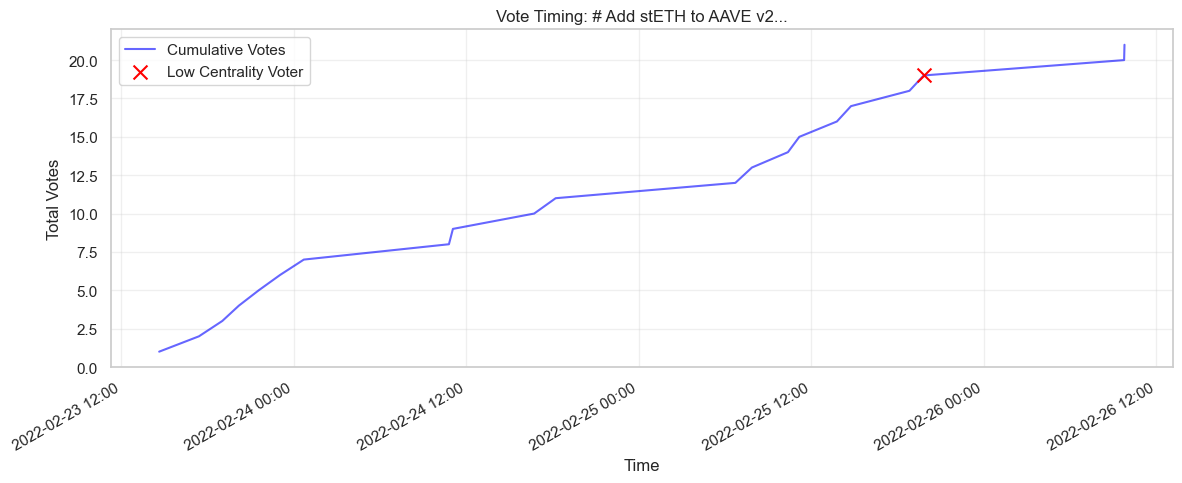

Found match: Proposal ID 62


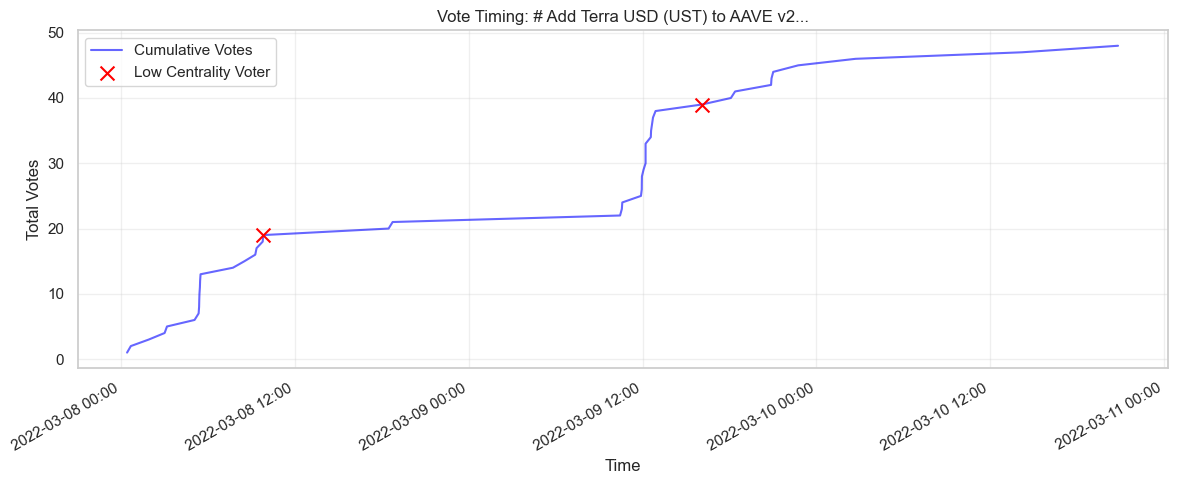

Found match: Proposal ID 65


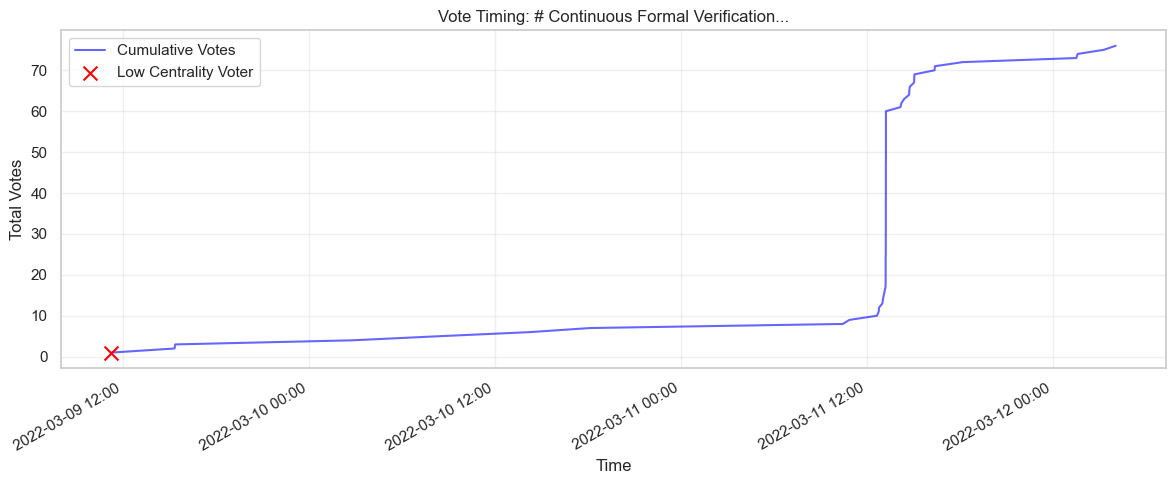

Found match: Proposal ID 66


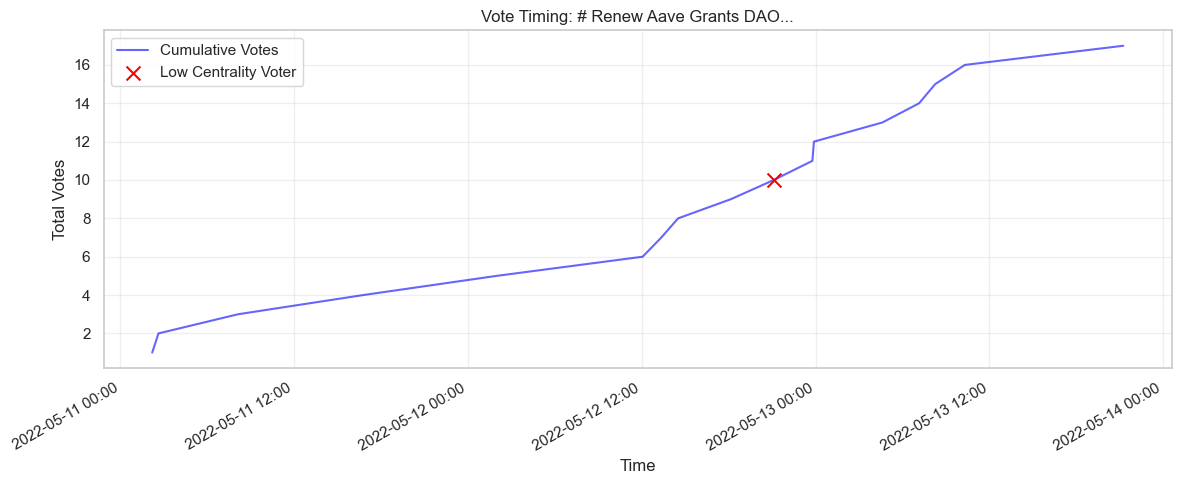

Found match: Proposal ID 73


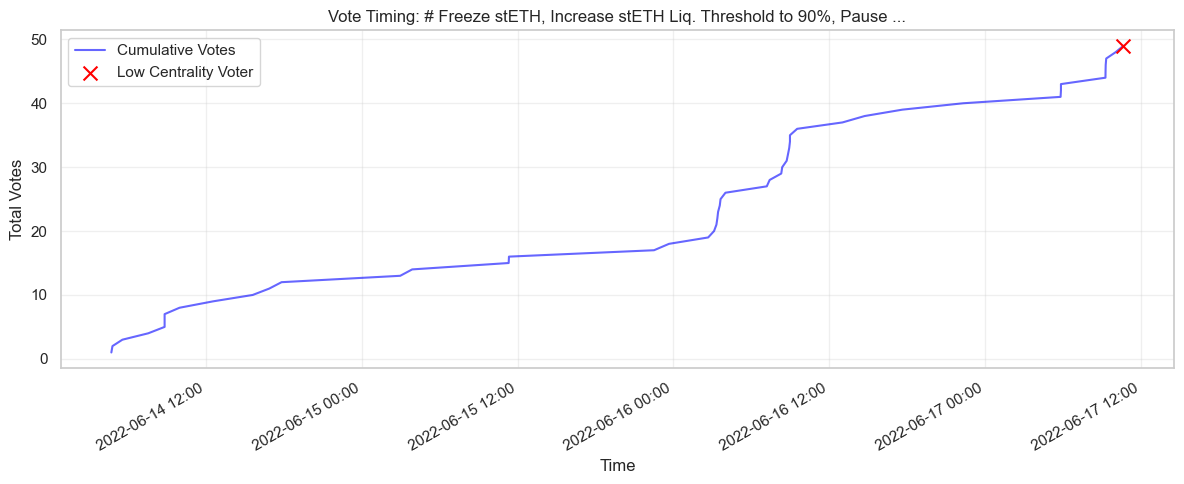

Found match: Proposal ID 83


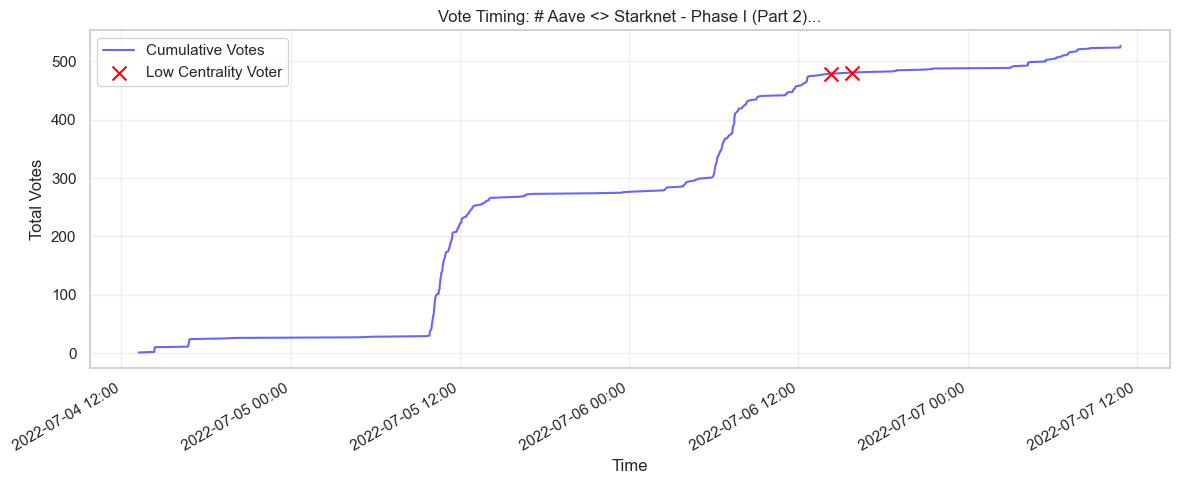

Found match: Proposal ID 85


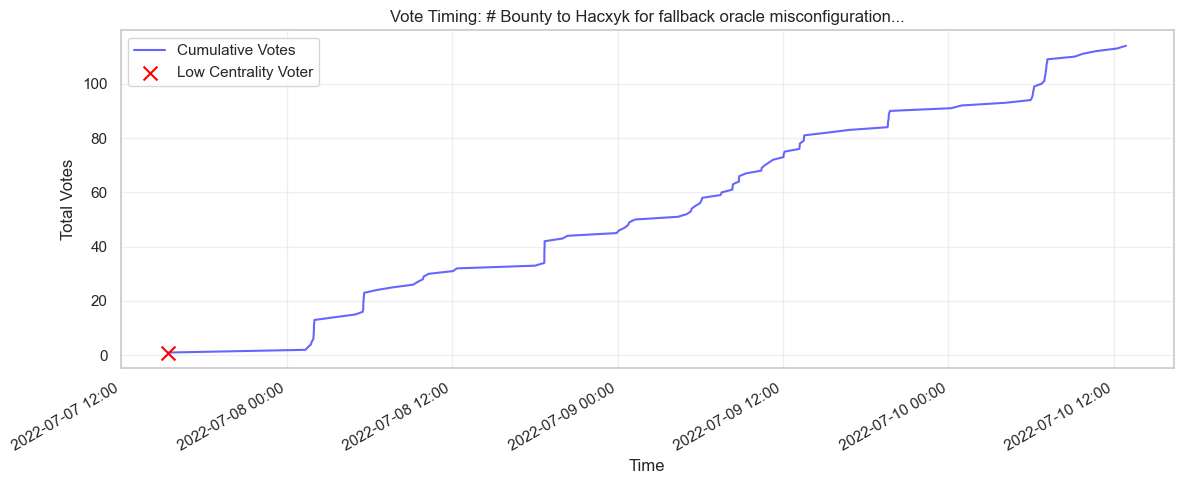

Found match: Proposal ID 86


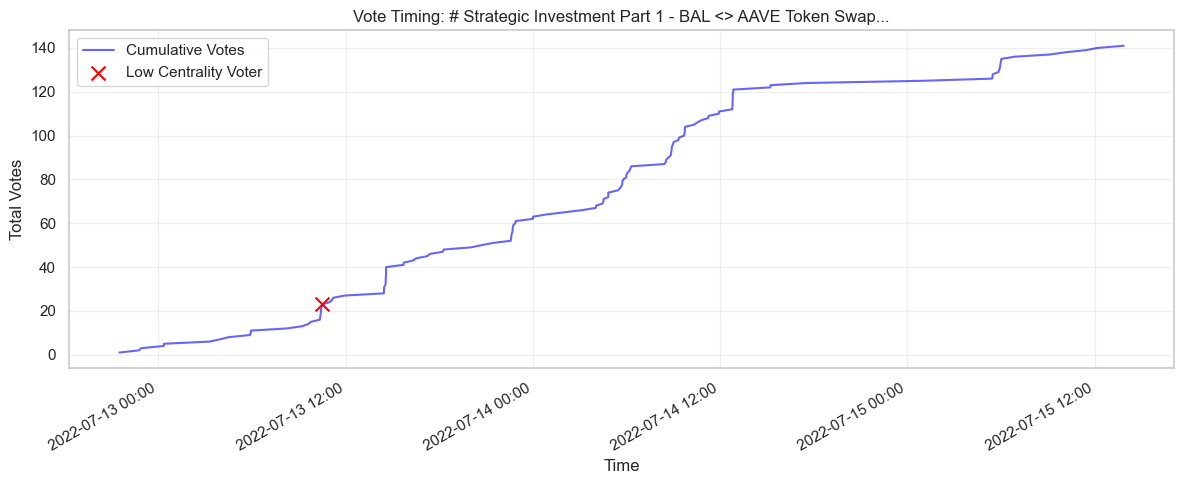

Found match: Proposal ID 87


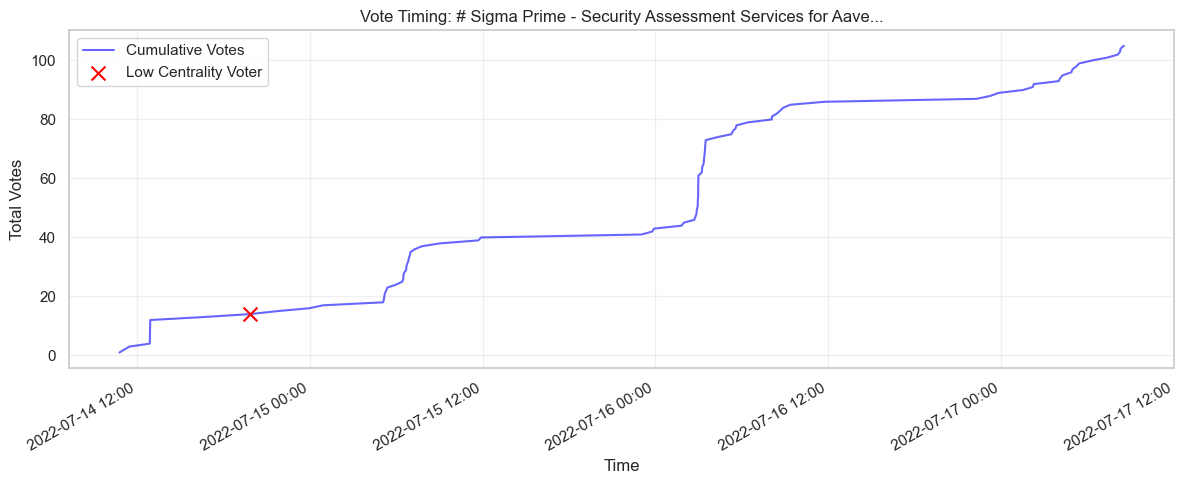

Found match: Proposal ID 88


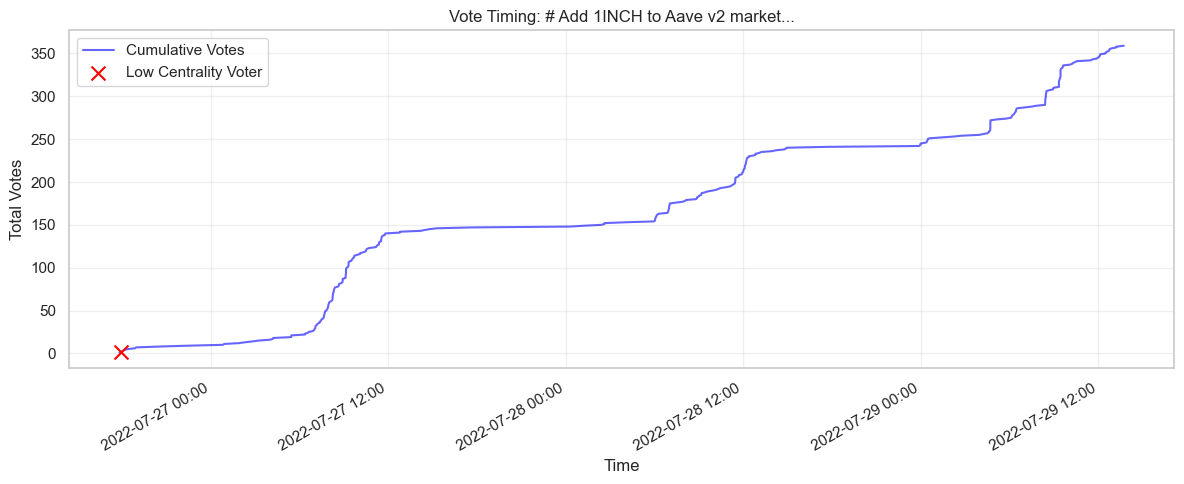

Found match: Proposal ID 90


In [51]:
# 1. Identify Low Centrality Voters (Bottom 10)
low_centrality_voters = set([add.split("_")[0] for add in centrality_df.tail(10).index ])
print(f"Tracking {len(low_centrality_voters)} voters with lowest Eigenvector centrality.")

def plot_cumulative_with_highlights(row):
    votes = row['votes']
    if not votes:
        return False
    
    # Sort votes by timestamp
    sorted_votes = sorted(votes, key=lambda x: pd.to_datetime(x['Timestamp']))
    timestamps = [pd.to_datetime(v['Timestamp']) for v in sorted_votes]
    
    # Cumulative count
    counts = range(1, len(timestamps) + 1)
    
    # Identify highlights
    highlight_times = []
    highlight_counts = []
    
    for i, vote in enumerate(sorted_votes):
        if vote['Voter_Address'] in low_centrality_voters:
            highlight_times.append(timestamps[i])
            highlight_counts.append(counts[i])
            
    # SKIP if no low centrality voters found
    if not highlight_times:
        return False
            
    # Plot
    plt.figure(figsize=(12, 5))
    
    # Main cumulative line
    plt.plot(timestamps, counts, label='Cumulative Votes', color='blue', alpha=0.6)
    
    # Highlights
    plt.scatter(highlight_times, highlight_counts, color='red', marker='x', s=100, zorder=5, label='Low Centrality Voter')
    
    plt.title(f"Vote Timing: {str(row['Proposal_Title'])[:60]}...")
    plt.xlabel("Time")
    plt.ylabel("Total Votes")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Format Date
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    plt.show()
    return True

# Plot the first 5 proposals that have low centrality votes
print("Searching for proposals with low centrality votes...")
plots_shown = 0
for i, row in transactions_df.iterrows():
    if plot_cumulative_with_highlights(row):
        print(f"Found match: Proposal ID {row['Onchain_ID']}")
        plots_shown += 1
        
    if plots_shown >= 20:
        break

In [52]:
# Calculate HITS (Hubs and Authorities)
try:
    hubs, authorities = nx.hits(G, max_iter=1000, normalized=True)
    
    # Create DataFrame
    hits_df = pd.DataFrame({
        'Hub_Score': pd.Series(hubs),
        'Authority_Score': pd.Series(authorities)
    })
    
    # Sort by Authority Score
    hits_df = hits_df.sort_values('Authority_Score', ascending=False)
    
    print("Top 20 Voters by Authority Score (HITS):")
    print(hits_df.head(20))
    
    print("\nTop 20 Voters by Hub Score (HITS):")
    print(hits_df.sort_values('Hub_Score', ascending=False).head(20))
    
except nx.PowerIterationFailedConvergence:
    print("HITS algorithm failed to converge.")

Top 20 Voters by Authority Score (HITS):
                                                Hub_Score  Authority_Score
0xea172676E4105e92Cc52DBf45fD93b274eC96676_FOR   0.038719         0.171191
0x329c54289Ff5D6B7b7daE13592C6B1EDA1543eD4_FOR   0.020966         0.170786
0xB933AEe47C438f22DE0747D57fc239FE37878Dd1_FOR   0.043352         0.149990
0x1855f41B8A86e701E33199DE7C25d3e3830698ba_FOR   0.086263         0.116015
0xE4594A66d9507fFc0d4335CC240BD61C1173E666_FOR   0.076617         0.107518
0x13BDaE8c5F0fC40231F0E6A4ad70196F59138548_FOR   0.061929         0.088664
0x2cc1ADE245020FC5AAE66Ad443e1F66e01c54Df1_FOR   0.111410         0.059734
0x57ab7ee15cE5ECacB1aB84EE42D5A9d0d8112922_FOR   0.121566         0.058269
0x8659D0BB123Da6D16D9394C7838BA286c2207d0E_FOR   0.124026         0.038990
0x8787FC2De4De95c53e5E3a4e5459247D9773ea52_FOR   0.123038         0.038843
0xDf06A761D286C0ae835173236E1f12f1379E4977_FOR   0.093517        -0.000000
0x62a43123FE71f9764f26554b3F5017627996816a_FOR   0.039405  

In [64]:
import random

# 1. Identify Candidate Pairs from Apriori (Support > 50%)
# We only check pairs that co-occur frequently to save computation
candidate_pairs = []
for _, row in pairwise_rules.iterrows():
    u = clean_node_label(row['antecedents'])
    v = clean_node_label(row['consequents'])
    candidate_pairs.append((u, v))

print(f"Testing temporal dependence for {len(candidate_pairs)} candidate pairs.")

# 2. Function to Calculate Temporal Confidence
def calculate_temporal_confidence(transactions_list, pairs_to_check):
    """
    Calculates P(u votes before v | u votes) for each pair.
    Returns a list of edges (u, v, confidence) where confidence > 0.8
    """
    # Pre-process transactions for fast lookup: ProposalID -> {Voter: Timestamp}
    # (In this simulation, we pass the list of vote dicts directly)
    
    pair_stats = {pair: {'before_count': 0, 'total_u_votes': 0} for pair in pairs_to_check}
    
    # Count total votes for 'u' (antecedent) globally first? 
    # Actually, standard confidence is P(B|A). Temporal confidence is P(B after A | A).
    # Let's iterate through proposals.
    
    for votes in transactions_list:
        # Create a map: Voter -> Timestamp
        # We use the 'vote_item' string (e.g. "Addr_FOR") to match Apriori nodes
        voter_times = {v['vote_item']: v['Timestamp'] for v in votes}
        
        for u, v in pairs_to_check:
            if u in voter_times:
                pair_stats[(u, v)]['total_u_votes'] += 1
                
                if v in voter_times:
                    # Check temporal order
                    if voter_times[u] < voter_times[v]:
                        pair_stats[(u, v)]['before_count'] += 1
                        
    # Calculate Confidence
    edges = []
    for (u, v), stats in pair_stats.items():
        if stats['total_u_votes'] > 0:
            conf = stats['before_count'] / stats['total_u_votes']
            if conf > 0.8: # Threshold from experiment design
                edges.append((u, v, conf))
                
    return edges

# 3. Function to Calculate HITS from Edges
def get_hits_scores(edges):
    if not edges:
        return {}, {}
        
    G_temp = nx.DiGraph()
    for u, v, w in edges:
        G_temp.add_edge(u, v, weight=w)
        
    try:
        h, a = nx.hits(G_temp, max_iter=500, normalized=True)
        return h, a
    except:
        return {}, {}

Testing temporal dependence for 61 candidate pairs.


In [65]:
# Configuration
n_permutations = 100 # Increase to 1000 for final analysis
null_hub_scores = {voter: [] for voter in G.nodes()}
null_auth_scores = {voter: [] for voter in G.nodes()}

# Prepare Data Structure for Fast Permutation
# List of [ {vote_item: timestamp, ...}, ... ]
original_data = []
for _, row in transactions_df.iterrows():
    original_data.append(row['votes'])

print(f"Starting Null Model Simulation ({n_permutations} permutations)...")

for i in range(n_permutations):
    if i % 10 == 0: print(f"Permutation {i}/{n_permutations}...")
    
    # Create Null Dataset (Shuffle Timestamps per Proposal)
    null_transactions = []
    for votes in original_data:
        # Extract timestamps
        timestamps = [v['Timestamp'] for v in votes]
        # Shuffle them
        random.shuffle(timestamps)
        
        # Re-assign to voters
        null_votes = []
        for j, vote in enumerate(votes):
            null_vote = vote.copy()
            null_vote['Timestamp'] = timestamps[j]
            null_votes.append(null_vote)
        
        null_transactions.append(null_votes)
        
    # 1. Calculate Null Confidence
    null_edges = calculate_temporal_confidence(null_transactions, candidate_pairs)
    
    # 2. Calculate Null HITS
    h_null, a_null = get_hits_scores(null_edges)
    
    # 3. Store Scores
    for voter in null_hub_scores:
        null_hub_scores[voter].append(h_null.get(voter, 0))
        null_auth_scores[voter].append(a_null.get(voter, 0))

print("Simulation Complete.")

Starting Null Model Simulation (100 permutations)...
Permutation 0/100...
Permutation 10/100...
Permutation 20/100...
Permutation 30/100...
Permutation 40/100...
Permutation 50/100...
Permutation 60/100...
Permutation 70/100...
Permutation 80/100...
Permutation 90/100...
Simulation Complete.


In [66]:
# Calculate Observed HITS (using the Temporal Definition)
print("Calculating Observed Temporal HITS...")
obs_edges = calculate_temporal_confidence(original_data, candidate_pairs)
obs_hubs, obs_auths = get_hits_scores(obs_edges)

results = []

if not obs_hubs:
    print("No significant temporal edges found in the observed data (Confidence > 0.8).")
    print("Try lowering the confidence threshold in 'calculate_temporal_confidence' or checking 'candidate_pairs'.")
else:
    for voter in obs_hubs.keys():
        # Observed Scores
        h_obs = obs_hubs.get(voter, 0)
        a_obs = obs_auths.get(voter, 0)
        
        # Null Distributions
        h_null_dist = null_hub_scores.get(voter, [])
        a_null_dist = null_auth_scores.get(voter, [])
        
        # Calculate P-Values
        # p = (Count Null >= Observed) / Total Permutations
        # If null dist is empty (shouldn't happen if perms ran), default to 0 or 1? 
        # If we have no null samples, we can't calculate p-value.
        if not h_null_dist:
            p_hub = 1.0
            p_auth = 1.0
        else:
            p_hub = sum(1 for h in h_null_dist if h >= h_obs) / len(h_null_dist)
            p_auth = sum(1 for a in a_null_dist if a >= a_obs) / len(a_null_dist)
        
        results.append({
            'Voter': voter,
            'Obs_Hub': h_obs,
            'P_Value_Hub': p_hub,
            'Obs_Auth': a_obs,
            'P_Value_Auth': p_auth
        })

# Create DataFrame with explicit columns to prevent KeyError
df_results = pd.DataFrame(results, columns=['Voter', 'Obs_Hub', 'P_Value_Hub', 'Obs_Auth', 'P_Value_Auth'])

if not df_results.empty:
    # Filter for Significance (p < 0.05)
    significant_hubs = df_results[df_results['P_Value_Hub'] < 0.05].sort_values('Obs_Hub', ascending=False)
    significant_auths = df_results[df_results['P_Value_Auth'] < 0.05].sort_values('Obs_Auth', ascending=False)

    print(f"Found {len(significant_hubs)} significant Hubs and {len(significant_auths)} significant Authorities.")

    print("\nTop Significant Hubs (Temporal Leaders):")
    display(significant_hubs.head(10))

    print("\nTop Significant Authorities (Temporal Followers):")
    display(significant_auths.head(10))
else:
    print("Result DataFrame is empty.")

Calculating Observed Temporal HITS...
No significant temporal edges found in the observed data (Confidence > 0.8).
Try lowering the confidence threshold in 'calculate_temporal_confidence' or checking 'candidate_pairs'.
Result DataFrame is empty.
